In [ ]:
import spotipy
from spotipy.oauth2 import SpotifyClientCredentials
from datetime import datetime
from lyricsgenius import Genius
import json, time
import requests
import spacy
import pandas as pd
import locationtagger
import nltk
from transformers import AutoTokenizer, AutoModelForTokenClassification
from transformers import pipeline
from bs4 import BeautifulSoup
import re
from geoparser import Geoparser
from geoparser.modules import SpacyRecognizer, SentenceTransformerResolver
import gc
from collections import defaultdict
import geopandas as gpd
from shapely.geometry import Point, MultiPoint
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import imageio
import numpy as np
import math
from scipy.stats import spearmanr
import statsmodels.api as sm
import warnings
warnings.filterwarnings("ignore")

c:\Users\yanni\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [32]:
CLIENT_ID = "73178afb90c449ec9990eed032135fb9"
CLIENT_SECRET = "6400e88437a84f2c869ba399cfedf819"
sp = spotipy.Spotify(auth_manager=SpotifyClientCredentials(
    client_id=CLIENT_ID,
    client_secret=CLIENT_SECRET
))

# I built a spotify playlist with some country songs I think are relevant because they have some potential location name problems/unique cases

playlist_link = "https://open.spotify.com/playlist/4NyiYd73gT7VZ7NQFwDNSJ?si=c4d55e2ee85f4d64" # link to the test playlist in spotify
playlist_URI = playlist_link.split("/")[-1].split("?")[0] # get the relevant part of the link

In [35]:
results = sp.playlist_tracks(playlist_URI)

test_songs = []

# extract song title, artists and release year (of the album the song is in) from the playlist
for item in results["items"]:
    track = item["track"]
    title = track["name"]
    artists = ", ".join([artist["name"] for artist in track["artists"]])
    release_date = track["album"]["release_date"]
    if len(release_date) == 4:
        year = datetime.strptime(release_date, "%Y").year
    else:
        year = datetime.strptime(release_date, "%Y-%m-%d").year
    test_songs.append((title, artists, year))

print(test_songs)

[('Bastante Cordón', 'Rick Trevino', 2010), ('Big Iron', 'Marty Robbins', 1959), ('Luckenbach, Texas (Back to the Basics of Love) (feat. Willie Nelson)', 'Waylon Jennings, Willie Nelson', 2006), ('When I Die, Just Let Me Go To Texas', 'Ed Bruce', 1977), ('Amarillo By Morning', 'George Strait', 2011), ('Tulsa Time', 'Don Williams', 2004), ('I Got Mexico', 'Eddy Raven', 1997), ('Smoky Mountain Rain', 'Ronnie Milsap', 2006), ('Write This Down', 'George Strait', 2004), ('Marina Del Rey', 'George Strait', 2007), ('Everywhere', 'Tim McGraw', 1997)]


In [34]:
# function to extract lyrics from Genius by Song name and Artist

def genius_lyrics(song_list):
    bearer = "u5iKazB9-AySWP3gl1a3kcca9CmIbTIv4aeKtSPJPykP5ApCNjuqIuJA1fetJ4Yr"
    genius = Genius(bearer, skip_non_songs=True, remove_section_headers=True, timeout=15)
    songs_data = []
    for title, artist, year in song_list:
        try:
            song = genius.search_song(title, artist) # search for the song in Genius
            if song: #lots of songs are not in Genius/do not have lyrics there
                lyrics = song.lyrics.replace("\n", " ") # no line breaks
                songs_data.append({ # create list of dictionaries with song title, artists, lyrics and release year
                    "title": title,
                    "artist": artist,
                    "lyrics": lyrics,
                    "release_year": year
                })
        except Exception as e:
            print(f"error for {title} by {artist}: {e}")
        time.sleep(5) # in order not to overload Genius with requests
    return songs_data

In [36]:
test_songs_data = genius_lyrics(test_songs)

with open("Test_data/GIR_all_test_songs.json", "w", encoding="utf-8") as f: # create json file with the resulting list
    json.dump(test_songs_data, f, ensure_ascii=False, indent=2)


Searching for "Bastante Cordón" by Rick Trevino...
No results found for: 'Bastante Cordón Rick Trevino'
Searching for "Big Iron" by Marty Robbins...
Done.
Searching for "Luckenbach, Texas (Back to the Basics of Love) (feat. Willie Nelson)" by Waylon Jennings, Willie Nelson...
Done.
Searching for "When I Die, Just Let Me Go To Texas" by Ed Bruce...
Done.
Searching for "Amarillo By Morning" by George Strait...
Done.
Searching for "Tulsa Time" by Don Williams...
Done.
Searching for "I Got Mexico" by Eddy Raven...
Done.
Searching for "Smoky Mountain Rain" by Ronnie Milsap...
Done.
Searching for "Write This Down" by George Strait...
Done.
Searching for "Marina Del Rey" by George Strait...
Done.
Searching for "Everywhere" by Tim McGraw...
Done.


In [2]:
#use spacy SM as NLP model
with open("Test_data/GIR_all_test_songs.json", "r", encoding="utf-8") as f:
    songs = json.load(f)

songs_df = pd.DataFrame(songs)
nlp = spacy.load("en_core_web_sm") # natural language processing model
docs = list(nlp.pipe(songs_df["lyrics"].tolist(), n_process=2, batch_size=100)) # takes list of all lyrics, runs NLP on it and saves all entities in the lyrics
test_results = []
for i, doc in enumerate(docs):
    entities = [ent.text for ent in doc.ents if ent.label_ in ["GPE"]]  # use only geopolitical entities (e.g. names of cities)
    test_results.append({
        "title": songs_df.loc[i, "title"],
        "artist": songs_df.loc[i, "artist"],
        "release_year": songs_df.loc[i, "release_year"],
        "locations": list(set(entities))  # all geopolitical locations, no duplicates
    })
test_results_df = pd.DataFrame(test_results)
test_results_df

,title,artist,release_year,locations
0,Big Iron,Marty Robbins,1959,"[Texas, Arizona]"
1,"Luckenbach, Texas (Back to the Basics of Love)...","Waylon Jennings, Willie Nelson",1977,"[Luckenbach, Texas]"
2,"When I Die, Just Let Me Go To Texas",Ed Bruce,1977,"[Texas, Detroit City, San Antone, Milwaukee, N..."
3,Amarillo By Morning,George Strait,1983,"[Houston, San Antone, Texas]"
4,Tulsa Time,Don Williams,1978,"[Livin, Oklahoma, Hollywood, Talkin, Tulsa, Ar..."
5,I Got Mexico,Eddy Raven,1997,[Mexico]
6,Smoky Mountain Rain,Ronnie Milsap,2006,[LA]
7,Write This Down,George Strait,1999,[Cause]
8,Marina Del Rey,George Strait,1982,"[Tears, Tennessee, hidden beach]"
9,Everywhere,Tim McGraw,1997,"[Texas, Oklahoma, Albuquerque, Georgia, Arizon..."


In [3]:
# do the same again but with another NLP model (spacy TRF)
with open("Test_data/GIR_all_test_songs.json", "r", encoding="utf-8") as f:
    songs = json.load(f)

songs_df = pd.DataFrame(songs)
nlp2 = spacy.load("en_core_web_trf")
docs2 = list(nlp2.pipe(songs_df["lyrics"].tolist(), n_process=2, batch_size=100))
test_results2 = []
for i, doc in enumerate(docs2):
    entities = [ent.text for ent in doc.ents if ent.label_ in ["GPE"]]
    test_results2.append({
        "title": songs_df.loc[i, "title"],
        "artist": songs_df.loc[i, "artist"],
        "release_year": songs_df.loc[i, "release_year"],
        "locations": list(set(entities))
    })
test_results_df2 = pd.DataFrame(test_results2)
test_results_df2

,title,artist,release_year,locations
0,Big Iron,Marty Robbins,1959,"[Texas, Agua Fria Rode]"
1,"Luckenbach, Texas (Back to the Basics of Love)...","Waylon Jennings, Willie Nelson",1977,"[Luckenbach, Texas]"
2,"When I Die, Just Let Me Go To Texas",Ed Bruce,1977,"[Texas, Detroit City, San Antone, Milwaukee, N..."
3,Amarillo By Morning,George Strait,1983,"[Texas, San Antone, Amarillo, Santa Fe, Houston]"
4,Tulsa Time,Don Williams,1978,"[Oklahoma, Hollywood, Tulsa, Arizona, California]"
5,I Got Mexico,Eddy Raven,1997,[Mexico]
6,Smoky Mountain Rain,Ronnie Milsap,2006,"[LA, Knoxville, Gatlinburg]"
7,Write This Down,George Strait,1999,[]
8,Marina Del Rey,George Strait,1982,"[Marina Del Rey, Tennessee]"
9,Everywhere,Tim McGraw,1997,"[Monterey, Texas, Oklahoma, Albuquerque, Georg..."


In [4]:
# the same again, with a third NLP model (locationtagger)
with open("Test_data/GIR_all_test_songs.json", "r", encoding="utf-8") as f:
    songs = json.load(f)

songs_df = pd.DataFrame(songs)
test_results3 = []
for i, row in songs_df.iterrows():
    lyrics_text = row["lyrics"]
    place_entity = locationtagger.find_locations(text = lyrics_text)
    locations = list(set(place_entity.cities))
    test_results3.append({
        "title": songs_df.loc[i, "title"],
        "artist": songs_df.loc[i, "artist"],
        "release_year": songs_df.loc[i, "release_year"],
        "locations": locations
    })
test_results_df3 = pd.DataFrame(test_results3)
test_results_df3

,title,artist,release_year,locations
0,Big Iron,Marty Robbins,1959,"[Agua Fria, Ranger]"
1,"Luckenbach, Texas (Back to the Basics of Love)...","Waylon Jennings, Willie Nelson",1977,"[Four, Newbury, Newberry, Hatfield]"
2,"When I Die, Just Let Me Go To Texas",Ed Bruce,1977,"[Milwaukee, Hell, New York, Dallas]"
3,Amarillo By Morning,George Strait,1983,"[Amarillo, Houston, Santa]"
4,Tulsa Time,Don Williams,1978,"[Hollywood, Tulsa, California, Pontiac]"
5,I Got Mexico,Eddy Raven,1997,[Mexico]
6,Smoky Mountain Rain,Ronnie Milsap,2006,[Knoxville]
7,Write This Down,George Strait,1999,[]
8,Marina Del Rey,George Strait,1982,"[Marina Del Rey, Marina del Rey, Marina, Tenne..."
9,Everywhere,Tim McGraw,1997,"[Albuquerque, Carolina, Dallas]"


In [5]:
#do the same again, with a fourth NLP model (bert base NER)
tokenizer = AutoTokenizer.from_pretrained("dslim/bert-base-NER")
model = AutoModelForTokenClassification.from_pretrained("dslim/bert-base-NER")
ner_pipeline = pipeline("ner", model=model, tokenizer=tokenizer, aggregation_strategy="simple")

with open("Test_data/GIR_all_test_songs.json", "r", encoding="utf-8") as f:
    songs = json.load(f)

songs_df = pd.DataFrame(songs)
test_results4 = []

for i, row in songs_df.iterrows():
    lyrics = row["lyrics"]
    entities = ner_pipeline(lyrics)

    # Extract only LOC labels
    locs = list(set([ent["word"] for ent in entities if ent["entity_group"] in ["LOC"]]))

    test_results4.append({
        "title": row["title"],
        "artist": row["artist"],
        "release_year": row["release_year"],
        "locations": locs
    })

test_results_df4 = pd.DataFrame(test_results4)
test_results_df4
    

,title,artist,release_year,locations
0,Big Iron,Marty Robbins,1959,"[##gua Fria Rode, A, Arizona, Texas]"
1,"Luckenbach, Texas (Back to the Basics of Love)...","Waylon Jennings, Willie Nelson",1977,"[##fields, Luckenbach, Hatfield, Texas]"
2,"When I Die, Just Let Me Go To Texas",Ed Bruce,1977,"[Texas Texas, Texas, Detroit City, San Antone,..."
3,Amarillo By Morning,George Strait,1983,"[Texas, San Antone, Amarillo, Santa Fe, Houston]"
4,Tulsa Time,Don Williams,1978,"[Oklahoma, Pontiac, Hollywood, Tulsa, Arizona,..."
5,I Got Mexico,Eddy Raven,1997,[Mexico]
6,Smoky Mountain Rain,Ronnie Milsap,2006,"[Mountain, ##moky Mountain, LA, Knoxville, ##m..."
7,Write This Down,George Strait,1999,[]
8,Marina Del Rey,George Strait,1982,"[Marina Del Rey, Tennessee]"
9,Everywhere,Tim McGraw,1997,"[Texas, Oklahoma, Albuquerque, Georgia, Arizon..."


In [2]:
geoparser = Geoparser(recognizer = SpacyRecognizer(model_name = 'en_core_web_trf'))

text = "Paris is the capital of France."
docs = geoparser.parse(text)

# Access results
for toponym in docs[0].toponyms:
    print(f"{toponym.text} -> {toponym.location.data}")

Batches: 100%|██████████| 5/5 [00:00<00:00, 11.20it/s]


Paris -> {'geonameid': 2988507, 'name': 'Paris', 'name_no_parens': 'Paris', 'asciiname': 'Paris', 'asciiname_no_parens': 'Paris', 'alternatenames': "Baariis,Bahliz,Baris,Lungsod ng Paris,Lutece,Lutetia,Lutetia Parisorum,Lutèce,PAR,Pa-ri,Paarys,Palika,Paname,Pantruche,Paraeis,Paras,Pari,Paries,Parigge,Pariggi,Parighji,Parigi,Pariis,Pariisi,Pariizu,Pariižu,Parij,Parijs,Paris,Parisi,Parixe,Pariz,Parize,Parizh,Parizh osh,Parizh',Parizo,Parizs,Pariž,Parys,Paryz,Paryzh,Paryzius,Paryż,Paryžius,Paräis,París,Paríž,Parîs,Parĩ,Parī,Parīze,Paříž,Páras,Párizs,Pʻariz,Ville-Lumiere,Ville-Lumière,ba li,barys,pairisa,pali,pari,paris,parys,paryzh,perisa,pryz,pyaris,pyarisa,pyrs,Παρίσι,Париж,Париж ош,Парижь,Париз,Парис,Парыж,Паріж,Փարիզ,פאריז,פריז,باريس,پارىژ,پاريس,پاریس,پیرس,ܦܐܪܝܣ,पॅरिस,पेरिस,पैरिस,প্যারিস,ਪੈਰਿਸ,પૅરિસ,பாரிஸ்,పారిస్,ಪ್ಯಾರಿಸ್,പാരിസ്,ปารีส,ཕ་རི།,ပါရီမြို့,პარიზი,ፓሪስ,ប៉ារីស,パリ,巴黎,파리", 'latitude': 48.85341, 'longitude': 2.3488, 'feature_class': 'P', 'feature_code': 'PPLC', 'feature_name': 'c

The actual locations in the lyrics are:
- Big Iron: Agua Fria (though imaginary), Texas (though a name), Arizona
- Luckenbach, Texas (Back to the Basics of Love): Luckenbach, Texas
- When I die, Just Let Me Go To Texas: Texas, New York, Detroit City, Dallas, Milwaukee, San Antone
- Amarillo By Morning: Amarillo, San Antone, Houston, Santa Fe, Texas
- Tulsa Time: Oklahoma, Arizona, California, Tulsa, Hollywood
- I Got Mexico: Mexico
- Smoky Mountain Rain: LA, Knoxville, Gatlinburg
- Write This Down: []
- Marina Del Rey: Marina Del Rey, Tennessee
- Everywhere: Albuquerque, Arizona, Monterey, Georgia, Carolina, Oklahoma, Dallas, Texas

In [17]:
with open("C:/Studium/Semester9/Geographic Information Retrieval/Project/Test_data/geoparse_test_results.json", "r", encoding="utf-8") as f:
    test_results5 = json.load(f)

In [33]:
#Agua Fria (though imaginary), Texas (though a name), Arizona
print(test_results[0]["locations"]) #found 2/3, found Arizona
print(test_results2[0]["locations"]) #found 1.5/3, did not find Arizona
print(test_results3[0]["locations"]) #found 1/3 + more, did not find Arizona
print(test_results4[0]["locations"]) #found 2.5/3 + more, found Arizona

#model 1 is best

['Texas', 'Arizona']
['Texas', 'Agua Fria Rode']
['Agua Fria', 'Ranger']
['##gua Fria Rode', 'A', 'Arizona', 'Texas']


In [34]:
#Luckenbach, Texas
print(test_results[1]["locations"]) #found 2/2
print(test_results2[1]["locations"]) #found 2/2
print(test_results3[1]["locations"]) #found 0/2 + more
print(test_results4[1]["locations"]) #found 2/2 + more

#model 1 and 2 are best

['Luckenbach', 'Texas']
['Luckenbach', 'Texas']
['Four', 'Newbury', 'Newberry', 'Hatfield']
['##fields', 'Luckenbach', 'Hatfield', 'Texas']


In [35]:
#Texas, New York, Detroit City, Dallas, Milwaukee, San Antone
print(test_results[2]["locations"]) #found 6/6
print(test_results2[2]["locations"]) #found 6/6
print(test_results3[2]["locations"]) #found 3/6 + more
print(test_results4[2]["locations"]) #found 6/6 + more

#model 1 and 2 are best

['Texas', 'Detroit City', 'San Antone', 'Milwaukee', 'New York', 'Dallas']
['Texas', 'Detroit City', 'San Antone', 'Milwaukee', 'New York', 'Dallas']
['Milwaukee', 'Hell', 'New York', 'Dallas']
['Texas Texas', 'Texas', 'Detroit City', 'San Antone', 'Milwaukee', 'New York', 'Hell', 'Dallas', 'heaven']


In [36]:
#Amarillo, San Antone, Houston, Santa Fe, Texas
print(test_results[3]["locations"]) #found 3/5
print(test_results2[3]["locations"]) #found 5/5
print(test_results3[3]["locations"]) #found 2/5
print(test_results4[3]["locations"]) #found 5/5

#model 2 and 4 are best

['Houston', 'San Antone', 'Texas']
['Texas', 'San Antone', 'Amarillo', 'Santa Fe', 'Houston']
['Amarillo', 'Houston', 'Santa']
['Texas', 'San Antone', 'Amarillo', 'Santa Fe', 'Houston']


In [37]:
#Oklahoma, Arizona, California, Tulsa, Hollywood
print(test_results[4]["locations"]) #found 5/5 + more
print(test_results2[4]["locations"]) #found 5/5
print(test_results3[4]["locations"]) #found 3/5 + more
print(test_results4[4]["locations"]) #found 5/5 + more

#model 2 is best

['Livin', 'Oklahoma', 'Hollywood', 'Talkin', 'Tulsa', 'Arizona', 'California']
['Oklahoma', 'Hollywood', 'Tulsa', 'Arizona', 'California']
['Hollywood', 'Tulsa', 'California', 'Pontiac']
['Oklahoma', 'Pontiac', 'Hollywood', 'Tulsa', 'Arizona', 'California']


In [38]:
#Mexico
print(test_results[5]["locations"]) #found 1/1
print(test_results2[5]["locations"]) #found 1/1
print(test_results3[5]["locations"]) #found 1/1
print(test_results4[5]["locations"]) #found 1/1

#all models are best

['Mexico']
['Mexico']
['Mexico']
['Mexico']


In [39]:
#LA, Knoxville, Gatlinburg
print(test_results[6]["locations"]) #found 1/3
print(test_results2[6]["locations"]) #found 3/3
print(test_results3[6]["locations"]) #found 1/3
print(test_results4[6]["locations"]) #found 3/3 + more

#model 2 is best

['LA']
['LA', 'Knoxville', 'Gatlinburg']
['Knoxville']
['Mountain', '##moky Mountain', 'LA', 'Knoxville', '##moky', 'Gatlinburg', 'S']


In [40]:
# []
print(test_results[7]["locations"]) #found something
print(test_results2[7]["locations"]) #found nothing
print(test_results3[7]["locations"]) #found nothing
print(test_results4[7]["locations"]) #found nothing

#model 2, 3 and 4 are best

['Cause']
[]
[]
[]


In [41]:
#Marina Del Rey, Tennessee
print(test_results[8]["locations"]) #found 1/2 + more
print(test_results2[8]["locations"]) #found 2/2
print(test_results3[8]["locations"]) #found 2/2 + more
print(test_results4[8]["locations"]) #found 2/2

#models 2 and 4 are best

['Tears', 'Tennessee', 'hidden beach']
['Marina Del Rey', 'Tennessee']
['Marina Del Rey', 'Marina del Rey', 'Marina', 'Tennessee']
['Marina Del Rey', 'Tennessee']


In [42]:
#Albuquerque, Arizona, Monterey, Georgia, Carolina, Oklahoma, Dallas, Texas
print(test_results[9]["locations"]) #found 7/8
print(test_results2[9]["locations"]) #found 8/8
print(test_results3[9]["locations"]) #found 3/8
print(test_results4[9]["locations"]) #found 7/8

#model 2 is best

['Texas', 'Oklahoma', 'Albuquerque', 'Georgia', 'Arizona', 'Carolina', 'Dallas']
['Monterey', 'Texas', 'Oklahoma', 'Albuquerque', 'Georgia', 'Arizona', 'Carolina', 'Dallas']
['Albuquerque', 'Carolina', 'Dallas']
['Texas', 'Oklahoma', 'Albuquerque', 'Georgia', 'Arizona', 'Carolina', 'Monterey Girl', 'Dallas']


Overall, the second NLP model (spacy TRF) performed best, therefore, I will use it later in the location extraction.

I will run the Irchel Geoparser locally (because the kernel always crashed in the Jupyter Notebook) and extract cities and coordinates, as well as US states.

In [ ]:
with open("C:/Studium/Semester9/Geographic Information Retrieval/Project/Test_data/geoparse_test_results.json", "r", encoding="utf-8") as f:
    test_results5 = json.load(f)

print(test_results5[0]["cities"])
print(test_results5[0]["states"])
print(test_results5[1]["cities"])
print(test_results5[1]["states"])
print(test_results5[2]["cities"])
print(test_results5[2]["states"])
print(test_results5[3]["cities"])
print(test_results5[3]["states"])
print(test_results5[4]["cities"])
print(test_results5[4]["states"])
print(test_results5[5]["cities"])
print(test_results5[5]["states"])
print(test_results5[6]["cities"])
print(test_results5[6]["states"])
print(test_results5[7]["cities"])
print(test_results5[7]["states"])
print(test_results5[8]["cities"])
print(test_results5[8]["states"])
print(test_results5[9]["cities"])
print(test_results5[9]["states"])



[]
['Texas']
[['Luckenbach', 30.17909, -98.75781]]
['Texas']
[['Detroit City', 42.33143, -83.04575], ['Milwaukee', 43.0389, -87.90647], ['Dallas', 32.78306, -96.80667], ['San Antone', 29.42412, -98.49363]]
['New York', 'Texas']
[['Santa Fe', 29.37801, -95.10576], ['Amarillo', 35.222, -101.8313], ['Houston', 29.76328, -95.36327], ['San Antone', 29.42412, -98.49363]]
['Texas']
[['Tulsa', 36.15398, -95.99277]]
['Oklahoma', 'California', 'Arizona']
[]
[]
[['Knoxville', 35.96064, -83.92074]]
[]
[]
[]
[['Marina Del Rey', 33.98162, -118.45371]]
['Tennessee']
[['Dallas', 32.78306, -96.80667], ['Albuquerque', 35.08449, -106.65114], ['Monterey', 36.61468, -121.90218]]
['Oklahoma', 'Texas', 'Georgia', 'Arizona']


This generally looks quite okay. Some mistakes are that LA and Hollywood are not recognized (they are recognized as some sort of area, but not the correct one) and that New York is not always found because sometimes it is mistaken as a state. I do filter out states but NOT New York because most likely, if New York is mentioned in a song, the city is meant and not the state.

Therefore, I will combine the use of Geoparser and the raw spacy TRF output in my final result. I will run all the lyrics through the Geoparser and then add the cities that are in the spaCy TRF output but not in the Geoparser output for this song. I will probably have to do this semi-manually.

Now, the corpus has to be created. I decided to use Wikipedia for this, as there is an extensive list of relevant Country songs for every year, dating back to 1920. Because the first Billboard charts were published at the start of 1944, I will use this as a start year. 2017 will be the end year because from 2018 onwards, American and Australian artists are lumped together, making analysis harder. The timespan that is used in this study is therefore 1944-2017, spanning a total of 74 years.

Because Wikipedia has multiple formats (to display the top Country songs, depending on the year, I need mulpitle ways to extract the songs:
1944-1947: "Number one hits" + "Top Hillbilly-Folk (Country) Recordings {year}"
1948: "Number one hits" + "Top Hillbilly-Folk (Country) Recordings {year}" (other format)
1949: "Number one hits" + "Top Country Records of {year}"
1950-1951: "Number one hits" + "Other major hits"
1952-1963: "United States" + "Other major hits"
1964-1979: "United States" + "Singles released by American artists"
1980-2000, 2013-2017: "Singles released by American artists"
2001-2012: "Top hits of the year"

In [12]:
def wiki_extractor(year):
    url = f"https://en.wikipedia.org/wiki/{year}_in_country_music"

    request_headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) " # something ChatGPT proposed
                  "AppleWebKit/537.36 (KHTML, like Gecko) "
                  "Chrome/120.0.0.0 Safari/537.36"
    }

    response = requests.get(url, headers=request_headers)
    response.raise_for_status()

    soup = BeautifulSoup(response.text, "html.parser")

    all_headers = soup.find_all(["h2","h3","h4"])
    
    # create list of all relevant headers in the wikipedia page
    header_list = []
    for h in all_headers:
        if "Number one hits" in h.get_text():
            header_list.append(h)
        if "Top Hillbilly" in h.get_text():
            header_list.append(h)
        if "Top country" in h.get_text():
            header_list.append(h)
        if "Other major hits" in h.get_text():
            header_list.append(h)
        if "United States" in h.get_text():
            header_list.append(h)
        if "Singles released by American artists" in h.get_text():
            header_list.append(h)
        if "Top hits of the year" in h.get_text():
            header_list.append(h)

    if len(header_list) == 0:
        raise ValueError("no headers available")
    
    songs_year = []
    for header in header_list:

        # extract table of section
        table = header.find_next("table")
        rows = table.find_all("tr")

        # extract column titles of table
        table_titles = [th.get_text(strip=True) for th in rows[0].find_all("th")]

        # extract all songs of the year
        for row in rows[1:]:
            cols = row.find_all(["td", "th"])
            if len(cols) != len(table_titles):
                continue # skip if row does not have all the columns
            entry = {table_titles[i]: cols[i].get_text(strip=True) for i in range(len(table_titles))} #dictionary with all column titles
            title_options = ["Single", "Title", "Single name", "Single Name"] #it's not always the same on Wikipedia
            for option in title_options:
                if option in entry:
                    title_colname = option
            title = re.sub(r'\s*\[\d+\]$', '', entry[title_colname])  #extract the title of the song without Wikipedia references
            title = title.strip('"\'') #remove quotation marks at the start and end
            entry = {table_titles[i]: cols[i].get_text(" ", strip=True) for i in range(len(table_titles))} #again, to extract artists
            artist = entry["Artist"] #it is always the same on Wikipedia
            songs_year.append((title, artist, year))

    songs_year = list(dict.fromkeys(songs_year)) #create dictionary with all songs (automatically removes duplicates)
    
    return songs_year

Now, I add all songs from 1944 to 2017 to a dictionary

In [13]:
# extract all the songs from 1944 to 2017 from Wikipedia

all_songs = {}
for year in range(1944, 2018):
    all_songs[year] = wiki_extractor(year)

Then, I create a list with all the songs of the form [(title1, artist1, year1), (title2, artist2, year2), (etc)]

In [14]:
all_songs_tuples = []
for years in all_songs.values(): # iterate through years (with all the songs)
    for song in years: # iterate through songs within the year
        all_songs_tuples.append(song)
all_songs_tuples

[("Pistol Packin' Mama", 'Al Dexter and His Troopers', 1944),
 ("Pistol Packin' Mama", 'Bing Crosby and the Andrews Sisters', 1944),
 ('Ration Blues', 'Louis Jordan And His Tympany Five', 1944),
 ('Rosalita', 'Al Dexter and His Troopers', 1944),
 ('They Took the Stars Out of Heaven', 'Floyd Tillman', 1944),
 ('So Long Pal', 'Al Dexter and His Troopers', 1944),
 ('Too Late to Worry, Too Blue to Cry', 'Al Dexter and His Troopers', 1944),
 ('Straighten Up and Fly Right', 'The King Cole Trio', 1944),
 ("Is You Is or Is You Ain't My Baby",
  'Louis Jordan And His Tympany Five',
  1944),
 ("Soldier's Last Letter", 'Ernest Tubb', 1944),
 ('Smoke on the Water', 'Red Foley', 1944),
 ("I'm Wastin' My Tears on You", 'Tex Ritter', 1944),
 ('Too Late To Worry, Too Blue To Cry', 'Al Dexter and His Troopers', 1944),
 ('Try Me One More Time', 'Ernest Tubb', 1944),
 ("I'm Wastin' My Tears on You", 'Tex Ritter and His Texans', 1944),
 ("You're From Texas", 'Bob Wills and His Texas Playboys', 1944),
 ("T

Now, I clean up the names by removing second artists (featurings, etc.) by looking for keywords

In [15]:
# clean up the names (if possible no multi-artists on a single song)

def artist_cleaner(song_list):
    song_list_clean = []
    burn_list = [" and ", " with ", " featuring ", " And ", " With ", " Featuring ", " (featuring ", " (Featuring ", " (feat. ", " (with ", " (With ", " , "]
    for song in song_list:
        title, artist, year = song
        for word in burn_list:
            if word in artist:
                artist = artist.split(word)[0].strip() #remove everything after the connector word (including connector word)
        song_list_clean.append((title, artist, year))
    return song_list_clean

I run the function

In [ ]:
all_songs_tuples_clean = artist_cleaner(all_songs_tuples) #all songs with (mostly) only one artist

In [34]:
with open("Data/all_songs_tuples_clean.json", "w", encoding="utf-8") as f: # create json file with the resulting list
    json.dump(all_songs_tuples_clean, f, ensure_ascii=False, indent=2)

Here, I print out the number of songs that are in Wikipedia. I also create chunks of 1000 songs each so that I don't lose everything with one error.

In [ ]:
print(len(all_songs_tuples_clean))

song_chunks = [] #create chunks of 1000 songs so that it all works smoothly and there are some checkpoints
for i in range(0,len(all_songs_tuples_clean), 1000):
    song_chunks.append(all_songs_tuples_clean[i:i+1000])

8073


In the following few code blocks, I look for the lyrics of the songs, chunkwise, and store the results in a list of dictionaries of the form [{title: title1, artist: artist1, lyrics: lyrics1, year: year1}, {dict2}, {dict3}]

In [44]:

all_songs_data_1000 = genius_lyrics(song_chunks[0])
with open("Data/all_song_data_1000.json", "w", encoding="utf-8") as f: # create json file with the resulting list
    json.dump(all_songs_data_1000, f, ensure_ascii=False, indent=2)

Searching for "Pistol Packin' Mama" by Al Dexter...
Done.
Searching for "Pistol Packin' Mama" by Bing Crosby...
Done.
Searching for "Ration Blues" by Louis Jordan...
Done.
Searching for "Rosalita" by Al Dexter...
Done.
Searching for "They Took the Stars Out of Heaven" by Floyd Tillman...
No results found for: 'They Took the Stars Out of Heaven Floyd Tillman'
Searching for "So Long Pal" by Al Dexter...
No results found for: 'So Long Pal Al Dexter'
Searching for "Too Late to Worry, Too Blue to Cry" by Al Dexter...
Done.
Searching for "Straighten Up and Fly Right" by The King Cole Trio...
Done.
Searching for "Is You Is or Is You Ain't My Baby" by Louis Jordan...
Done.
Searching for "Soldier's Last Letter" by Ernest Tubb...
Done.
Searching for "Smoke on the Water" by Red Foley...
Done.
Searching for "I'm Wastin' My Tears on You" by Tex Ritter...
No results found for: 'I'm Wastin' My Tears on You Tex Ritter'
Searching for "Too Late To Worry, Too Blue To Cry" by Al Dexter...
Done.
Searching 

In [38]:
all_songs_data_2000 = genius_lyrics(song_chunks[1])
with open("Data/all_song_data_2000.json", "w", encoding="utf-8") as f: # create json file with the resulting list
    json.dump(all_songs_data_2000, f, ensure_ascii=False, indent=2)

Searching for "Next Time" by Ernest Tubb...
No results found for: 'Next Time Ernest Tubb'
Searching for "Ninety-Nine" by Bill Anderson...
Done.
Searching for "Old Moon" by Betty Foley [ 1 ]...
No results found for: 'Old Moon Betty Foley [ 1 ]'
Searching for "Partners" by Jim Reeves...
Done.
Searching for "Poor Old Heartsick Me" by Margie Bowes...
Done.
Searching for "Problems" by The Everly Brothers...
Done.
Searching for "Sailor Man" by Johnnie & Jack...
Done.
Searching for "Sal's Got a Sugar Lip" by Johnny Horton...
Done.
Searching for "Set Him Free" by Skeeter Davis...
Done.
Searching for "So Many Times" by Roy Acuff...
Done.
Searching for "So Soon" by Jimmy C. Newman...
No results found for: 'So Soon Jimmy C. Newman'
Searching for "Soldier's Joy" by Hawkshaw Hawkins...
Done.
Searching for "Somebody's Back in Town" by The Wilburn Brothers...
Done.
Searching for "Ten Thousand Drums" by Carl Smith...
Done.
Searching for "Tennessee Stud" by Eddy Arnold...
Done.
Searching for "Thanks a 

In [40]:
all_songs_data_3000 = genius_lyrics(song_chunks[2])
with open("Data/all_song_data_3000.json", "w", encoding="utf-8") as f: # create json file with the resulting list
    json.dump(all_songs_data_3000, f, ensure_ascii=False, indent=2)

Searching for "She Wears My Ring" by Ray Price...
Done.
Searching for "She Went a Little Bit Further" by Faron Young...
Done.
Searching for "Something Pretty" by Wynn Stewart...
No results found for: 'Something Pretty Wynn Stewart'
Searching for "Something Special" by Mel Tillis...
Done.
Searching for "Son of Hickory Holler's Tramp" by O. C. Smith...
No results found for: 'Son of Hickory Holler's Tramp O. C. Smith'
Searching for "The Sounds of Goodbye" by Tommy Cash...
No results found for: 'The Sounds of Goodbye Tommy Cash'
Searching for "Stop the Sun" by Bonnie Guitar...
No results found for: 'Stop the Sun Bonnie Guitar'
Searching for "The Straight Life" by Bobby Goldsboro...
Done.
Searching for "Sundown Mary" by Billy Walker...
Done.
Searching for "Sweet Rosie Jones" by Buck Owens...
Done.
Searching for "Take Me Along with You" by Van Trevor...
No results found for: 'Take Me Along with You Van Trevor'
Searching for "Take Me As I Am (Or Let Me Go)" by Ray Price...
Done.
Searching for

In [42]:
all_songs_data_4000 = genius_lyrics(song_chunks[3])
with open("Data/all_song_data_4000.json", "w", encoding="utf-8") as f: # create json file with the resulting list
    json.dump(all_songs_data_4000, f, ensure_ascii=False, indent=2)

Searching for "Don't Let the Good Times Fool You" by Melba Montgomery...
No results found for: 'Don't Let the Good Times Fool You Melba Montgomery'
Searching for "Dreaming My Dreams with You" by Waylon Jennings...
Done.
Searching for "Even If I Have to Steal" by Mel Street...
No results found for: 'Even If I Have to Steal Mel Street'
Searching for "Everything's the Same (Ain't Nothing Changed)" by Billy Swan...
Done.
Searching for "The Farthest Thing from My Mind" by Ray Price...
No results found for: 'The Farthest Thing from My Mind Ray Price'
Searching for "Flat Natural Born Good-Timin' Man" by Gary Stewart...
Done.
Searching for "For a Minute There" by Johnny Paycheck...
Done.
Searching for "Forbidden Angel" by Mel Street...
No results found for: 'Forbidden Angel Mel Street'
Searching for "Forgive and Forget" by Eddie Rabbitt...
Done.
Searching for "Freda Comes, Freda Goes" by Bobby G. Rice...
Done.
Searching for "From Barroom to Bedrooms" by David Wills...
No results found for: 'Fr

In [46]:
all_songs_data_5000 = genius_lyrics(song_chunks[4])
with open("Data/all_song_data_5000.json", "w", encoding="utf-8") as f: # create json file with the resulting list
    json.dump(all_songs_data_5000, f, ensure_ascii=False, indent=2)

Searching for "1959" by John Anderson...
Done.
Searching for "Acapulco" by Johnny Duncan...
No results found for: 'Acapulco Johnny Duncan'
Searching for "Alice Doesn't Love Here Anymore" by Bobby Goldsboro...
No results found for: 'Alice Doesn't Love Here Anymore Bobby Goldsboro'
Searching for "All My Rowdy Friends (Have Settled Down)" by Hank Williams, Jr....
Done.
Searching for "All Roads Lead to You" by Steve Wariner...
Done.
Searching for "Am I Losing You" by Ronnie Milsap...
Done.
Searching for "Angel Flying Too Close to the Ground" by Willie Nelson...
Done.
Searching for "Any Which Way You Can" by Glen Campbell...
Done.
Searching for "Are You Happy Baby?" by Dottie West...
Done.
Searching for "The Baron" by Johnny Cash...
Done.
Searching for "Beautiful You" by The Oak Ridge Boys...
Done.
Searching for "Bet Your Heart on Me" by Johnny Lee...
Done.
Searching for "Between This Time and the Next Time" by Gene Watson...
Done.
Searching for "A Bridge That Just Won't Burn" by Conway Twi

In [18]:
all_songs_data_6000 = genius_lyrics(song_chunks[5])
with open("Data/all_song_data_6000.json", "w", encoding="utf-8") as f: # create json file with the resulting list
    json.dump(all_songs_data_6000, f, ensure_ascii=False, indent=2)

Searching for "You're Something Special to Me" by George Strait...
Done.
Searching for "You're Still New to Me" by Marie Osmond...
Done.
Searching for "You're the Last Thing I Needed Tonight" by John Schneider...
Done.
Searching for "Your Memory Ain't What It Used to Be" by Mickey Gilley...
No results found for: 'Your Memory Ain't What It Used to Be Mickey Gilley'
Searching for "80's Ladies" by K. T. Oslin...
No results found for: '80's Ladies K. T. Oslin'
Searching for "Ain't No Cure for Love" by Jennifer Warnes...
Done.
Searching for "All My Ex's Live in Texas" by George Strait...
Done.
Searching for "Am I Blue" by George Strait...
Done.
Searching for "American Me" by S-K-O...
No results found for: 'American Me S-K-O'
Searching for "Another World" by Crystal Gayle...
Done.
Searching for "Baby's Got a Hold on Me" by Nitty Gritty Dirt Band...
Done.
Searching for "Baby's Got a New Baby" by S-K-O...
No results found for: 'Baby's Got a New Baby S-K-O'
Searching for "The Bed You Made for M

In [20]:
all_songs_data_7000 = genius_lyrics(song_chunks[6])
with open("Data/all_song_data_7000.json", "w", encoding="utf-8") as f: # create json file with the resulting list
    json.dump(all_songs_data_7000, f, ensure_ascii=False, indent=2)

Searching for "When You Leave That Way You Can Never Go Back" by Confederate Railroad...
Done.
Searching for "Why Didn't I Think of That" by Doug Stone...
Done.
Searching for "Wild Man" by Ricky Van Shelton...
Done.
Searching for "Workin' Man's Ph.D" by Aaron Tippin...
Done.
Searching for "You Say You Will" by Trisha Yearwood...
Done.
Searching for "Addicted to a Dollar" by Doug Stone...
Done.
Searching for "Baby Likes to Rock It" by The Tractors...
Done.
Searching for "Be My Baby Tonight" by John Michael Montgomery...
Done.
Searching for "Before You Kill Us All" by Randy Travis...
Done.
Searching for "The Big One" by George Strait...
Done.
Searching for "The Boys and Me" by Sawyer Brown...
Done.
Searching for "The Call of the Wild" by Aaron Tippin...
Done.
Searching for "Callin' Baton Rouge" by Garth Brooks...
Done.
Searching for "The Cheap Seats" by Alabama...
Done.
Searching for "The City Put the Country Back in Me" by Neal McCoy...
Done.
Searching for "Daddy Never Was the Cadillac 

In [22]:
all_songs_data_8000 = genius_lyrics(song_chunks[7])
with open("Data/all_song_data_8000.json", "w", encoding="utf-8") as f: # create json file with the resulting list
    json.dump(all_songs_data_8000, f, ensure_ascii=False, indent=2)

Searching for "Hey Good Lookin" by Jimmy Buffett...
Done.
Searching for "Honesty (Write Me a List)" by Rodney Atkins...
Done.
Searching for "Hot Mama" by Trace Adkins...
Done.
Searching for "How Far" by Martina McBride...
Done.
Searching for "I Can't Sleep" by Clay Walker...
Done.
Searching for "I Go Back" by Kenny Chesney...
Done.
Searching for "I Got a Feelin" by Billy Currington...
Done.
Searching for "I Hate Everything" by George Strait...
Done.
Searching for "I Love You This Much" by Jimmy Wayne...
Done.
Searching for "I Wanna Do It All" by Terri Clark...
Done.
Searching for "I Want to Live" by Josh Gracin...
Done.
Searching for "If Nobody Believed in You" by Joe Nichols...
Done.
Searching for "If You Ever Stop Loving Me" by Montgomery Gentry...
Done.
Searching for "In a Real Love" by Phil Vassar...
Done.
Searching for "In My Daughter's Eyes" by Martina McBride...
Done.
Searching for "It Only Hurts When I'm Breathing" by Shania Twain...
Done.
Searching for "Let's Be Us Again" by L

In [23]:
all_songs_data_9000 = genius_lyrics(song_chunks[8])
with open("Data/all_song_data_9000.json", "w", encoding="utf-8") as f: # create json file with the resulting list
    json.dump(all_songs_data_9000, f, ensure_ascii=False, indent=2)

Searching for "Ask Me How I Know" by Garth Brooks...
Done.
Searching for "Baby, Let's Lay Down and Dance" by Garth Brooks...
Done.
Searching for "Bar at the End of the World" by Kenny Chesney...
Done.
Searching for "Better Man" by Little Big Town...
Done.
Searching for "Black" by Dierks Bentley...
Done.
Searching for "Blue Ain't Your Color" by Keith Urban...
Done.
Searching for "Body Like a Back Road" by Sam Hunt...
Done.
Searching for "California" by Big & Rich...
Done.
Searching for "Craving You" by Thomas Rhett...
Done.
Searching for "The Dance" by Lauren Duski...
No results found for: 'The Dance Lauren Duski'
Searching for "Dear Hate" by Maren Morris...
Done.
Searching for "Deja Vu" by Lauren Duski...
Done.
Searching for "Dirt on My Boots" by Jon Pardi...
Done.
Searching for "Dirty Laundry" by Carrie Underwood...
Done.
Searching for "Do I Make You Wanna" by Billy Currington...
Done.
Searching for "Drinkin' Problem" by Midland...
Done.
Searching for "Drinkin' Too Much" by Sam Hunt..

I noticed that some artists were never found by Genius because there was a space between two abbreviation-letters. (for example: T. G. Sheppard instead of T.G. Sheppard or O. C. Smith instead of O.C. Smith). I corrected these cases and searched for lyrics again. I also looked for lyrics of songs that randomly threw an error again.

In [ ]:
# deal with some errors

all_songs_tuples_errors = []
pattern = re.compile(r"[A-Z]\.\s*[A-Z]\.")
for song in all_songs_tuples_clean:
    title, artist, year = song
    if pattern.search(artist):
        artist = re.sub(r"([A-Z]\.)\s*([A-Z]\.)", r"\1\2", artist)
        all_songs_tuples_errors.append((title, artist, year))
all_songs_tuples_errors.extend([("Golden Guitar", "Bill Anderson", 1966), ("I Love You Drops", "Bill Anderson", 1966), ("I'd Fight the World", "Jim Reeves", 1974), ("Near You", "George Jones", 1977), ("Heart Healer", "Mel Tillis", 1977), ("She's Just an Old Love Turned Memory", "Charley Price", 1977)])
print(all_songs_tuples_errors)

all_songs_data_errors = genius_lyrics(all_songs_tuples_errors)
with open("Data/all_song_data_errors.json", "w", encoding="utf-8") as f: # create json file with the resulting list
    json.dump(all_songs_data_errors, f, ensure_ascii=False, indent=2)

[("Son of Hickory Holler's Tramp", 'O.C. Smith', 1968), ("Old Home Filler-Up an' Keep On-a-Truckin' Cafe", 'C.W. McCall', 1974), ('Devil in the Bottle', 'T.G. Sheppard', 1975), ("(Hey Won't You Play) AnotherSomebody Done Somebody Wrong Song", 'B.J. Thomas', 1975), ("Tryin' to Beat the Morning Home", 'T.G. Sheppard', 1975), ('Convoy', 'C.W. McCall', 1975), ('Another Woman', 'T.G. Sheppard', 1975), ('Classified', 'C.W. McCall', 1975), ('Wolf Creek Pass', 'C.W. McCall', 1975), ('Show Me a Man', 'T.G. Sheppard', 1976), ('Solitary Man', 'T.G. Sheppard', 1976), ("There Won't Be No Country Music(There Won't Be No Rock 'n' Roll)", 'C.W. McCall', 1976), ("Lovin' On", 'T.G. Sheppard', 1977), ('Roses for Mama', 'C.W. McCall', 1977), ('Daylight', 'T.G. Sheppard', 1978), ("Don't Ever Say Goodbye", 'T.G. Sheppard', 1978), ('Mister D.J.', 'T.G. Sheppard', 1978), ('When Can We Do This Again', 'T.G. Sheppard', 1978), ("Last Cheater's Waltz", 'T.G. Sheppard', 1979), ('Happy Together', 'T.G. Sheppard', 1

I botched one song, oops.

In [45]:
the_one_song_oops = genius_lyrics([("I'd Fight the World", "Jim Reeves", 1974)])
with open("Data/the_one_song_oops.json", "w", encoding="utf-8") as f: # create json file with the resulting list
    json.dump(the_one_song_oops, f, ensure_ascii=False, indent=2)

Searching for "I'd Fight the World" by Jim Reeves...
Done.


I merge all these datasets into a single big one and remove duplicates

In [ ]:
#load all songs again
with open("Data/all_song_data_1000.json", "r", encoding = "utf-8") as f:
    all_songs_data_1000 = json.load(f)
with open("Data/all_song_data_2000.json", "r", encoding = "utf-8") as f:
    all_songs_data_2000 = json.load(f)
with open("Data/all_song_data_3000.json", "r", encoding = "utf-8") as f:
    all_songs_data_3000 = json.load(f)
with open("Data/all_song_data_4000.json", "r", encoding = "utf-8") as f:
    all_songs_data_4000 = json.load(f)
with open("Data/all_song_data_5000.json", "r", encoding = "utf-8") as f:
    all_songs_data_5000 = json.load(f)
with open("Data/all_song_data_6000.json", "r", encoding = "utf-8") as f:
    all_songs_data_6000 = json.load(f)
with open("Data/all_song_data_7000.json", "r", encoding = "utf-8") as f:
    all_songs_data_7000 = json.load(f)
with open("Data/all_song_data_8000.json", "r", encoding = "utf-8") as f:
    all_songs_data_8000 = json.load(f)
with open("Data/all_song_data_9000.json", "r", encoding = "utf-8") as f:
    all_songs_data_9000 = json.load(f)
with open("Data/all_song_data_errors.json", "r", encoding = "utf-8") as f:
    all_songs_data_errors = json.load(f)
with open("Data/the_one_song_oops.json", "r", encoding = "utf-8") as f:
    the_one_song_oops = json.load(f)

#combine them into single dataset
all_songs_data_complete = all_songs_data_1000 + all_songs_data_2000 + all_songs_data_3000 + all_songs_data_4000 + all_songs_data_5000 + all_songs_data_6000 + all_songs_data_7000 + all_songs_data_8000 + all_songs_data_9000 + all_songs_data_errors + the_one_song_oops
with open("Data/all_song_data_complete.json", "w", encoding="utf-8") as f:
    json.dump(all_songs_data_complete, f, ensure_ascii=False, indent=2)

# remove duplicate songs
all_songs_data_complete_no_duplicates = []
seen_keys = set()
for song in all_songs_data_complete:
    key = (song["title"], song["artist"], song["lyrics"]) #ignore release year because some songs are in two wikipedia pages
    if key not in seen_keys:
        seen_keys.add(key)
        all_songs_data_complete_no_duplicates.append(song)
with open("Data/all_song_data_complete_no_duplicates.json", "w", encoding="utf-8") as f:
    json.dump(all_songs_data_complete_no_duplicates, f, ensure_ascii=False, indent=2)

Number of songs with lyrics

In [96]:
with open("Data/all_song_data_complete.json", "r", encoding = "utf-8") as f:
    all_songs_data_complete = json.load(f)
len(all_songs_data_complete)

6812

Number of songs with lyrics (duplicates removed) and ratio to number of songs from Wikipedia.

In [ ]:
#some stats

lyrics_ratio = len(all_songs_data_complete_no_duplicates) / len(all_songs_tuples_clean)
print(len(all_songs_data_complete_no_duplicates)) #the number of the songs that had lyrics on Genius, without dupulicates
print(len(all_songs_tuples_clean))
print(lyrics_ratio)

6784
8073
0.8403319707667534


I did the location extraction with Irchel Geoparser locally in a python script because Jupyter could not handle it. I produced 340 files with 19-20 songs each.

Here, I add them all to a single dataset. geoparser_locations.json includes a list of dictionaries of all the songs. These dictionaries include the locations, partitioned by city and state. I also include a category "add_location", where additional locations found by the spaCy TRF model, that were wrongly geolocalized by the Irchel Geoparser, are stored.

Note: in the local python script, I already removed all the locations that were (according to Irchel Geoparser) not in the USA.

In [29]:
#import Geoparser results (there are 340 files which have to be added to a single dataset)

geoparser_locations = []
for i in range(1,341):
    chunk_path = f"Data/GeoparserV2/geoparser_results_chunk_{i}_songs.json"
    with open(chunk_path, "r", encoding = "utf-8") as f:
        songs = json.load(f)
        for song in songs:
            geoparser_locations.append({
                "title": song["title"],
                "artist": song["artist"],
                "release_year": song["release_year"],
                "cities": song["cities"],
                "states": song["states"],
                "add_locations": [] #where additional locations that the spaCyTRF-only run found are stored later on
            })
geoparser_locations_df = pd.DataFrame(geoparser_locations)
geoparser_locations_df.to_json("Data/geoparser_locations.json", orient="records", force_ascii=False, indent=2)

This is a function to find all the locations in the songs again. This time with the pure spaCy TRF model, without the Irchel Geoparser. This means that it's only doing toponym recognition, no resolution. For some reason, this creates additional results.

In [ ]:
# function with the best model (spaCy TRF) to extract the locations (this will be used to complement the Irchel Geoparser locations)
def location_finder(file_path):
    with open(file_path, "r", encoding="utf-8") as f:
        songs = json.load(f)

    songs_df = pd.DataFrame(songs)
    nlp = spacy.load("en_core_web_trf")
    docs = list(nlp.pipe(songs_df["lyrics"].tolist(), n_process=2, batch_size=100))
    all_songs_locations = []
    for i, doc in enumerate(docs):
        entities = [ent.text for ent in doc.ents if ent.label_ in ["GPE"]]
        all_songs_locations.append({
            "title": songs_df.loc[i, "title"],
            "artist": songs_df.loc[i, "artist"],
            "lyrics": songs_df.loc[i, "lyrics"],
            "locations": list(set(entities)), #no duplicates
            "release_year": int(songs_df.loc[i, "release_year"])
        })
    return all_songs_locations

I call the function and create the file all_songs_locations.json. It includes a list of dictionaries with every song and the corresponding locations.

In [76]:
all_songs_locations = location_finder("Data/all_song_data_complete_no_duplicates.json")
with open("Data/all_songs_locations.json", "w", encoding="utf-8") as f:
    json.dump(all_songs_locations, f, ensure_ascii=False, indent=2)

Then, I remove all the songs without locations from this spaCy TRF-only file.

In [ ]:
#remove songs without any locations in the TRF only file

all_songs_locations_clean = []
for song in all_songs_locations:
    if song.get("locations") != []:
        all_songs_locations_clean.append(song)
    else:
        continue
with open("Data/all_songs_locations_clean.json", "w", encoding="utf-8") as f:
    json.dump(all_songs_locations_clean, f, ensure_ascii=False, indent=2)

I load the datasets and print their lengths

In [30]:
# load spaCyTRF-only location file and Geoparser location file

with open("Data/all_songs_locations_clean.json", "r", encoding = "utf-8") as f:
    trf_songs = json.load(f)

with open("Data/geoparser_locations.json", "r", encoding = "utf-8") as f:
    geoparser_songs = json.load(f)

print(len(trf_songs))
print(len(geoparser_songs))

959
6784


Now, we add all the spaCy TRF-only locations to the Geoparser results in the add_location key as values.

In [31]:
# We now add the spaCy TRF-only locations as additional locations to the Geoparser results, in case they are not already in cities

for trf_song in trf_songs:
    for geoparser_song in geoparser_songs:
        if trf_song["title"] == geoparser_song["title"] and trf_song["artist"] == geoparser_song["artist"]:
            for location in trf_song["locations"]:
                cities = [city[0] for city in geoparser_song["cities"]]
                states = geoparser_song["states"]
                add_locations = geoparser_song["add_locations"]
                if location not in cities and location not in states and location not in add_locations:
                    geoparser_song["add_locations"].append(location)
                else:
                    continue

with open("Data/locations_raw.json", "w", encoding="utf-8") as f:
    json.dump(geoparser_songs, f, ensure_ascii=False, indent=2)


Now, I remove all the completely empty songs where no locations at all were found.

In [33]:
geoparser_songs_clean = []
for song in geoparser_songs:
    if song.get("cities") != [] or song.get("states") != [] or song.get("add_locations") != []:
        geoparser_songs_clean.append(song)
    else:
        continue
        
with open("Data/geoparser_songs_clean.json", "w", encoding="utf-8") as f:
    json.dump(geoparser_songs_clean, f, ensure_ascii=False, indent=2)

len(geoparser_songs_clean)

982

Now, I rearrange the dictionaries. The city + coordinates become the key and I add a count. The number of times a city gets mentioned is the count. I also keep the artists, titles and release years. The additional locations are not used, for now.

In [36]:
with open("Data/geoparser_songs_clean.json", "r", encoding = "utf-8") as f:
    geoparser_songs_clean = json.load(f)

city_counts = {}
for song in geoparser_songs_clean:
    year = song.get("release_year")
    artist = song.get("artist")
    title = song.get("title")
    for city in song["cities"]:
        name, lat, lon, country, state, pop = city
        key = (name, lat, lon, country, state, pop)
        if key in city_counts:
            city_counts[key]["count"] += 1
            city_counts[key]["release_years"].append(year)
            city_counts[key]["artist"].append(artist)
            city_counts[key]["title"].append(title)
        else:
            city_counts[key] = {
                "count": 1,
                "release_years": [year],
                "artist": [artist],
                "title": [title]
            }
print(city_counts) #{(place1, lat1, lon1): {count: 1, release_years: [1999], artist: [Someone], title: [S omething]}, (place2, lat2, lon2): {dictionary2}}

{('Sea', 47.60621, -122.33207, 'US', 'WA', 780995): {'count': 1, 'release_years': [1944], 'artist': ['Gene Autry'], 'title': ["I'm Thinking Tonight Of My Blue Eyes"]}, ('Okinawa', 26.33583, 127.80139, 'JP', '47', 142752): {'count': 1, 'release_years': [1946], 'artist': ['Bob Wills'], 'title': ['White Cross on Okinawa']}, ('the Rio Grande', 23.82733, -103.03408, 'MX', '32', 32944): {'count': 1, 'release_years': [1946], 'artist': ['Bob Wills'], 'title': ['New Spanish Two Step']}, ('Dallas', 32.78306, -96.80667, 'US', 'TX', 1326087): {'count': 39, 'release_years': [1946, 1954, 1963, 1964, 1966, 1968, 1968, 1972, 1973, 1975, 1976, 1976, 1976, 1976, 1977, 1977, 1979, 1979, 1980, 1981, 1981, 1984, 1985, 1985, 1985, 1985, 1989, 1991, 1992, 1994, 1995, 1995, 1996, 1997, 1999, 2001, 2014, 2014, 2017], 'artist': ['Merle Travis', 'Wanda Jackson', 'Stonewall Jackson', 'George Hamilton IV', 'Buddy Starcher', 'Del Reeves', 'Nat Stuckey', 'Barbara Mandrell', 'Jim Ed Brown', 'Faron Young', 'Mel Tillis

Here, I consolidate for coordinates. Meaning that when multiple cities with the exact same name have different coordinates, the ones with the lower counts get appended to the one with the highest count. If two cities have the same count, the one with the higher population becomes the main city. This means that in the resulting dataset, there are no cities with the exact same name anymore.

In [40]:
# consolidate for coordinates (when a city with the same name was allocated multiple coordinates, they get put together (more frequent city is main city))
# 2 "Memphis", 1 "memphis" --> 1 "Memphis", 1 "memphis"
city_groups_same_coords = {}

for (name, lat, lon, country, state, pop), info in city_counts.items():
    key = name
    city_groups_same_coords.setdefault(key, []).append((name, lat, lon, country, state, pop, info["count"], info))

consolidated_coords = {}
for city_name, variants in city_groups_same_coords.items():
    variants.sort(key = lambda x: (x[6], x[5]), reverse = True) #sort city variants descending
    main_name, main_lat, main_lon, main_country, main_state, main_pop, main_count, main_info = variants[0] #if variants[0] and variants[1] have same count, then use the one with higher population?
    total_count = sum(v[6] for v in variants)

    all_years = []
    all_artists = []
    all_titles = []

    for _, _, _, _, _, _, _, info in variants:
        all_years.extend(info.get("release_years", []))
        all_artists.extend(info.get("artist", []))
        all_titles.extend(info.get("title", []))

    consolidated_coords[(main_name, main_lat, main_lon, main_country, main_state, main_pop)] = {
        "count": total_count,
        "release_years": all_years,
        "artists": all_artists,
        "titles": all_titles
    }

print(consolidated_coords)

city_list_geoparser = []
for (name, lat, lon, country, state, pop), count in consolidated_coords.items():
    city_list_geoparser.append({
        "city": name,
        "coords": [lat, lon],
        "country": country,
        "state": state,
        "pop": pop,
        "count": count
    })

with open("Data/city_list_geoparser.json", "w", encoding="utf-8") as f:
    json.dump(city_list_geoparser, f, ensure_ascii=False, indent=2)

{('Sea', 47.60621, -122.33207, 'US', 'WA', 780995): {'count': 1, 'release_years': [1944], 'artists': ['Gene Autry'], 'titles': ["I'm Thinking Tonight Of My Blue Eyes"]}, ('Okinawa', 26.33583, 127.80139, 'JP', '47', 142752): {'count': 1, 'release_years': [1946], 'artists': ['Bob Wills'], 'titles': ['White Cross on Okinawa']}, ('the Rio Grande', 23.82733, -103.03408, 'MX', '32', 32944): {'count': 1, 'release_years': [1946], 'artists': ['Bob Wills'], 'titles': ['New Spanish Two Step']}, ('Dallas', 32.78306, -96.80667, 'US', 'TX', 1326087): {'count': 40, 'release_years': [1946, 1954, 1963, 1964, 1966, 1968, 1968, 1972, 1973, 1975, 1976, 1976, 1976, 1976, 1977, 1977, 1979, 1979, 1980, 1981, 1981, 1984, 1985, 1985, 1985, 1985, 1989, 1991, 1992, 1994, 1995, 1995, 1996, 1997, 1999, 2001, 2014, 2014, 2017, 1998], 'artists': ['Merle Travis', 'Wanda Jackson', 'Stonewall Jackson', 'George Hamilton IV', 'Buddy Starcher', 'Del Reeves', 'Nat Stuckey', 'Barbara Mandrell', 'Jim Ed Brown', 'Faron Young'

Then, I put them both into lists to get the same data structure as before.

In [41]:
city_counts_list = []

for (name, lat, lon, country, state, pop), info in city_counts.items():
    city_counts_list.append({
        "city": name,
        "lat": lat,
        "lon": lon,
        "country": country,
        "state": state,
        "pop": pop,
        "count": info["count"],
        "release_years": info["release_years"],
        "artists": info["artist"],
        "titles": info["title"]
    })

with open("Data/city_counts.json", "w", encoding="utf-8") as f:
    json.dump(city_counts_list, f, ensure_ascii=False, indent=2)


consolidated_coords_list = []

for (name, lat, lon, country, state, pop), info in consolidated_coords.items():
    consolidated_coords_list.append({
        "city": name,
        "lat": lat,
        "lon": lon,
        "country": country,
        "state": state,
        "pop": pop,
        "count": info["count"],
        "release_years": info["release_years"],
        "artists": info["artists"],
        "titles": info["titles"]
    })

with open("Data/consolidated_coords.json", "w", encoding="utf-8") as f:
    json.dump(consolidated_coords_list, f, ensure_ascii=False, indent=2)

print(len(city_counts))
print(len(consolidated_coords))

279
261


The lengths show that 18 cities were removed because they had the same name as another city. Their songs were moved to the frequent, same city.

Below, I finally go through all the additional locations (add_locations) from before and append these locations/songs to the locations already identified. This means that only locations that were found before are respected. New locations, unfortunately, get thrown out.

In [42]:
# add the additional locations to the city list

with open("Data/consolidated_coords.json", "r", encoding = "utf-8") as f:
    consolidated_coords_list = json.load(f)

with open("Data/geoparser_songs_clean.json", "r", encoding = "utf-8") as f:
    geoparser_songs_clean = json.load(f)

for song in geoparser_songs_clean:
    title = song.get("title")
    artist = song.get("artist")
    year = song.get("release_year")
    add_locations = song.get("add_locations")
    for location in add_locations:
        for c_song in consolidated_coords_list:
            city = c_song.get("city")
            count = c_song.get("count")
            release_years = c_song.get("release_years")
            artists = c_song.get("artists")
            titles = c_song.get("titles")
            if location == city:
                c_song["count"] += 1
                c_song["release_years"].append(year)
                c_song["artists"].append(artist)
                c_song["titles"].append(title)

with open("Data/consolidated_coords_with_add_locations.json", "w", encoding="utf-8") as f:
    json.dump(consolidated_coords_list, f, ensure_ascii=False, indent=2)

Now, I also consolidate for name. This means that cities with the exact same coordinates but with different names (lowercase or uppercase, with or without "the", including state name or not, etc.) get merged. Again, the more frequent city is kept.

In [45]:
# consolidate for name (cities with the same coordinates get put together (more frequent one is main city))
# 1 ("Memphis", 23.456, 34.567), 1 ("the Memphis in Tennessee", 23.456, 34.567) --> 1 ("Memphis", 23.456, 34.567)
city_groups_same_coords = defaultdict(list)

for song in consolidated_coords_list:
    key = (song["lat"], song["lon"])
    city_groups_same_coords[key].append(song)

final_city_list = []
for (lat, lon), variants in city_groups_same_coords.items():
    variants_sorted = sorted(variants, key = lambda x: (x["count"], x["pop"]), reverse = True) #sort city variants descending
    main = variants_sorted[0]
    total_count = sum([v["count"] for v in variants])
    all_years = []
    all_artists = []
    all_titles = []
    for v in variants:
        all_years.extend(v["release_years"])
        all_artists.extend(v["artists"])
        all_titles.extend(v["titles"])
    final_city_list.append({
        "city": main["city"],
        "lat": lat,
        "lon": lon,
        "country": main["country"],
        "state": main["state"],
        "pop": main["pop"],
        "count": total_count,
        "release_years": all_years,
        "artists": all_artists,
        "titles": all_titles
    })

with open("Data/final_city_list.json", "w", encoding="utf-8") as f:
    json.dump(final_city_list, f, ensure_ascii=False, indent=2)

Then, I remove duplicates. These are created because sometimes in one song two locations have different names but the same coordinates. An example would be South Philly and Philly. Both have the same coordinates and thus get added twice. So one location could have the same song listed twice.

In [46]:
# remove rare duplicates that were just created (because two different locations with the same coordinates are put together)

def deduper(entry):
    seen = set()
    unique_songs = []

    for artist, title, year in zip(entry["artists"], entry["titles"], entry["release_years"]):
        key = (artist, title, year)
        if key not in seen:
            seen.add(key)
            unique_songs.append(key)

    entry["artists"] = [a for a, t, y in unique_songs]
    entry["titles"] = [t for a, t, y in unique_songs]
    entry["release_years"] = [y for a, t, y in unique_songs]
    entry["count"] = len(unique_songs)

    return entry

Here, the final list of all the cities gets created. I remove duplicate entries in a locations. And also, non-US cities get removed because I don't want them in my analysis.

In [48]:
final_city_list_clean = []
for entry in final_city_list:
    if entry["country"] != "US":
        continue
    clean_entry = deduper(entry)
    final_city_list_clean.append(clean_entry)


with open("Data/Final/final_city_list_clean.json", "w", encoding="utf-8") as f:
    json.dump(final_city_list_clean, f, ensure_ascii=False, indent=2)

Now, I also have to do the same thing with the US states. States are filtered out only on the basis of their names so there are no additional locations that are states. The exception is Alabama, which is often called Alabam.

Here, I just create a dictionary of all the states with the counts and song information in sub-dictionaries.

In [49]:
#create state list
with open("Data/geoparser_songs_clean.json", "r", encoding = "utf-8") as f:
    geoparser_songs_clean = json.load(f)

state_counts = {}
for song in geoparser_songs_clean:
    year = song.get("release_year")
    artist = song.get("artist")
    title = song.get("title")
    for state in song["states"]:
        if state in state_counts:
            state_counts[state]["count"] += 1
            state_counts[state]["release_years"].append(year)
            state_counts[state]["artist"].append(artist)
            state_counts[state]["title"].append(title)
        else:
            state_counts[state] = {
                "count": 1,
                "release_years": [year],
                "artist": [artist],
                "title": [title]
            }
    for location in song["add_locations"]:  #also look for "Alabam" in add_locations and add that to the "Alabama" count
        if location == "Alabam" and "Alabama" not in song["states"]:
            if "Alabama" in state_counts:
                state_counts["Alabama"]["count"] += 1
                state_counts["Alabama"]["release_years"].append(year)
                state_counts["Alabama"]["artist"].append(artist)
                state_counts["Alabama"]["title"].append(title)
            else:
                state_counts["Alabama"] = {
                    "count": 1,
                    "release_years": [year],
                    "artist": [artist],
                    "title": [title]
                }
    
print(state_counts) #{(place1, lat1, lon1): {count: 1, release_years: [1999], artist: [Someone], title: [S omething]}, (place2, lat2, lon2): {dictionary2}}

{'Texas': {'count': 100, 'release_years': [1944, 1946, 1948, 1948, 1953, 1955, 1960, 1960, 1962, 1962, 1963, 1964, 1965, 1967, 1968, 1968, 1968, 1970, 1970, 1971, 1972, 1974, 1974, 1975, 1975, 1975, 1976, 1976, 1976, 1976, 1976, 1976, 1976, 1977, 1977, 1977, 1978, 1979, 1979, 1979, 1980, 1980, 1980, 1980, 1980, 1980, 1980, 1981, 1983, 1983, 1984, 1984, 1984, 1985, 1985, 1985, 1985, 1985, 1986, 1986, 1986, 1987, 1987, 1988, 1988, 1988, 1988, 1988, 1988, 1989, 1989, 1989, 1989, 1990, 1990, 1991, 1991, 1991, 1992, 1992, 1993, 1993, 1994, 1995, 1995, 1995, 1996, 1996, 1996, 1996, 1997, 1998, 1998, 1999, 1999, 2003, 2005, 2006, 2006, 2010], 'artist': ['Bing Crosby', 'Merle Travis', 'Eddy Arnold', 'Ernest Tubb', 'Hank Snow', 'Ernest Tubb', 'Marty Robbins', 'Webb Pierce', 'Webb Pierce', 'Johnny Cash', 'Lester Flatt', 'George Hamilton IV', 'George Hamilton IV', 'David Houston', 'Dottie West', 'Billy Walker', 'Dave Dudley', 'Jeannie C. Riley', 'Roy Drusky', 'Jerry Lee Lewis', 'Red Simpson', 'Je

Then, I create a list of dictionaries again.

In [50]:
state_counts_list = []

for name, info in state_counts.items():
    state_counts_list.append({
        "state": name,
        "count": info["count"],
        "release_years": info["release_years"],
        "artists": info["artist"],
        "titles": info["title"]
    })

with open("Data/state_counts.json", "w", encoding="utf-8") as f:
    json.dump(state_counts_list, f, ensure_ascii=False, indent=2)


Now, I webscrape Wikipedia again and extract all the state centroids.

In [51]:
url = "https://en.wikipedia.org/wiki/List_of_geographic_centers_of_the_United_States"

request_headers = {
"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) " # something ChatGPT proposed
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/120.0.0.0 Safari/537.36"
}

response = requests.get(url, headers=request_headers)
response.raise_for_status()

soup = BeautifulSoup(response.text, "html.parser")

all_headers = soup.find_all(["h2","h3","h4"])

header_text = "Modern list of geographic centers"
for h in all_headers:
    if header_text in h.get_text():
        header = h
        break
table = header.find_next("table")
rows = table.find_all("tr")

state_centroids = []

for row in rows[1:]:
    cols = row.find_all(["td", "th"])
    state = cols[0].get_text(strip = True)
    coords = cols[2].get_text(strip = True)
    coords = coords.replace("\ufeff", "")
    matches = re.findall(r'(\d+°\d+′\d+″[NSWE])', coords)
    lat_text, lon_text = matches

    def dms_to_decimal(dms):
        match = re.match(r'(\d+)°(\d+)′(\d+)″([NSWE])', dms)
        deg, minute, sec, dir = match.groups()
        dec = float(deg) + float(minute)/60 + float(sec)/3600
        if dir in ["S", "W"]:
            dec = -dec
        return dec
    
    lat = dms_to_decimal(lat_text)
    lon = dms_to_decimal(lon_text)

    state_centroids.append({
        "state": state,
        "lat": round(lat, 4),
        "lon": round(lon, 4)
    })

state_centroids

[{'state': 'Alabama', 'lat': 32.7794, 'lon': -86.8286},
 {'state': 'Alaska', 'lat': 64.0686, 'lon': -152.2783},
 {'state': 'Arizona', 'lat': 34.2744, 'lon': -111.6603},
 {'state': 'Arkansas', 'lat': 34.8939, 'lon': -92.4425},
 {'state': 'California', 'lat': 37.1842, 'lon': -119.4697},
 {'state': 'Colorado', 'lat': 38.9972, 'lon': -105.5478},
 {'state': 'Connecticut', 'lat': 41.6219, 'lon': -72.7272},
 {'state': 'Delaware', 'lat': 38.9897, 'lon': -75.505},
 {'state': 'District of Columbia', 'lat': 38.91, 'lon': -77.0147},
 {'state': 'Florida', 'lat': 28.6306, 'lon': -82.4497},
 {'state': 'Georgia', 'lat': 32.6414, 'lon': -83.4425},
 {'state': 'Hawaii', 'lat': 20.2928, 'lon': -156.3736},
 {'state': 'Idaho', 'lat': 44.3508, 'lon': -114.6131},
 {'state': 'Illinois', 'lat': 40.0417, 'lon': -89.1964},
 {'state': 'Indiana', 'lat': 39.8942, 'lon': -86.2817},
 {'state': 'Iowa', 'lat': 42.075, 'lon': -93.4961},
 {'state': 'Kansas', 'lat': 38.4939, 'lon': -98.3772},
 {'state': 'Kentucky', 'lat': 

Then, I create the final state list with all the states and their coordinates (which is just the centroid)

In [52]:
final_state_list = []
for state_song in state_counts_list:
    state_name_song = state_song.get("state")
    count = state_song.get("count")
    release_years = state_song.get("release_years")
    artists = state_song.get("artists")
    titles = state_song.get("titles")
    for state_centroid in state_centroids:
        state_name_centroid = state_centroid.get("state")
        lat = state_centroid.get("lat")
        lon = state_centroid.get("lon")
        if state_name_song == state_name_centroid:
            final_state_list.append({
                "state": state_name_song,
                "lat": lat,
                "lon": lon,
                "count": count,
                "release_years": release_years,
                "artists": artists,
                "titles": titles
            })

with open("Data/Final/final_state_list.json", "w", encoding="utf-8") as f:
    json.dump(final_state_list, f, ensure_ascii=False, indent=2)

Function to split decades (40s, 50s, 60s, etc.)

In [67]:
def decade_splitter(upper_year, location_list):
    location_dict = {}
    for entry in location_list:
        if entry.get("city"):
            location = entry.get("city")
            lat = entry.get("lat")
            lon = entry.get("lon")
            state = entry.get("state")
            pop = entry.get("pop")
            release_years = entry.get("release_years")
            artists = entry.get("artists")
            titles = entry.get("titles")
        else:
            location = entry.get("state")
            lat = entry.get("lat")
            lon = entry.get("lon")
            release_years = entry.get("release_years")
            artists = entry.get("artists")
            titles = entry.get("titles")
        for year, artist, title in zip(release_years, artists, titles):
            if year < upper_year and year > (upper_year - 11):
                if location in location_dict:
                    location_dict[location]["count"] += 1
                    location_dict[location]["release_years"].append(year)
                    location_dict[location]["artists"].append(artist)
                    location_dict[location]["titles"].append(title)
                else:
                    if entry.get("city"):
                        location_dict[location] = {
                            "city": location,
                            "lat": lat,
                            "lon": lon,
                            "state": state,
                            "pop": pop,
                            "count": 1,
                            "release_years": [year],
                            "artists": [artist],
                            "titles": [title]
                        }
                    else:
                        location_dict[location] = {
                            "state": location,
                            "lat": lat,
                            "lon": lon,
                            "count": 1,
                            "release_years": [year],
                            "artists": [artist],
                            "titles": [title]
                        }

    final_location_list_decade = []
    for name, info in location_dict.items():
        if info.get("city"):
            final_location_list_decade.append({
                "city": name,
                "lat": info["lat"],
                "lon": info["lon"],
                "state": info["state"],
                "pop": info["pop"],
                "count": info["count"],
                "release_years": info["release_years"],
                "artists": info["artists"],
                "titles": info["titles"]
            })
        else:
            final_location_list_decade.append({
                "state": name,
                "lat": info["lat"],
                "lon": info["lon"],
                "count": info["count"],
                "release_years": info["release_years"],
                "artists": info["artists"],
                "titles": info["titles"]
            })
    
    return final_location_list_decade

Split the city list into decade lists.

In [69]:
with open("Data/Final/final_city_list_clean.json", "r", encoding = "utf-8") as f:
    final_city_list_clean = json.load(f)
    
final_city_list_40s = decade_splitter(1950, final_city_list_clean)
with open("Data/Final/final_city_list_40s.json", "w", encoding="utf-8") as f:
    json.dump(final_city_list_40s, f, ensure_ascii=False, indent=2)
    
final_city_list_50s = decade_splitter(1960, final_city_list_clean)
with open("Data/Final/final_city_list_50s.json", "w", encoding="utf-8") as f:
    json.dump(final_city_list_50s, f, ensure_ascii=False, indent=2)

final_city_list_60s = decade_splitter(1970, final_city_list_clean)
with open("Data/Final/final_city_list_60s.json", "w", encoding="utf-8") as f:
    json.dump(final_city_list_60s, f, ensure_ascii=False, indent=2)

final_city_list_70s = decade_splitter(1980, final_city_list_clean)
with open("Data/Final/final_city_list_70s.json", "w", encoding="utf-8") as f:
    json.dump(final_city_list_70s, f, ensure_ascii=False, indent=2)
    
final_city_list_80s = decade_splitter(1990, final_city_list_clean)
with open("Data/Final/final_city_list_80s.json", "w", encoding="utf-8") as f:
    json.dump(final_city_list_80s, f, ensure_ascii=False, indent=2)

final_city_list_90s = decade_splitter(2000, final_city_list_clean)
with open("Data/Final/final_city_list_90s.json", "w", encoding="utf-8") as f:
    json.dump(final_city_list_90s, f, ensure_ascii=False, indent=2)

final_city_list_00s = decade_splitter(2010, final_city_list_clean)
with open("Data/Final/final_city_list_00s.json", "w", encoding="utf-8") as f:
    json.dump(final_city_list_00s, f, ensure_ascii=False, indent=2)
    
final_city_list_10s = decade_splitter(2020, final_city_list_clean)
with open("Data/Final/final_city_list_10s.json", "w", encoding="utf-8") as f:
    json.dump(final_city_list_10s, f, ensure_ascii=False, indent=2)

Split the state list into decade lists.

In [70]:
with open("Data/Final/final_state_list.json", "r", encoding = "utf-8") as f:
    final_state_list = json.load(f)
    
final_state_list_40s = decade_splitter(1950, final_state_list)
with open("Data/Final/final_state_list_40s.json", "w", encoding="utf-8") as f:
    json.dump(final_state_list_40s, f, ensure_ascii=False, indent=2)

final_state_list_50s = decade_splitter(1960, final_state_list)
with open("Data/Final/final_state_list_50s.json", "w", encoding="utf-8") as f:
    json.dump(final_state_list_50s, f, ensure_ascii=False, indent=2)

final_state_list_60s = decade_splitter(1970, final_state_list)
with open("Data/Final/final_state_list_60s.json", "w", encoding="utf-8") as f:
    json.dump(final_state_list_60s, f, ensure_ascii=False, indent=2)

final_state_list_70s = decade_splitter(1980, final_state_list)
with open("Data/Final/final_state_list_70s.json", "w", encoding="utf-8") as f:
    json.dump(final_state_list_70s, f, ensure_ascii=False, indent=2)

final_state_list_80s = decade_splitter(1990, final_state_list)
with open("Data/Final/final_state_list_80s.json", "w", encoding="utf-8") as f:
    json.dump(final_state_list_80s, f, ensure_ascii=False, indent=2)

final_state_list_90s = decade_splitter(2000, final_state_list)
with open("Data/Final/final_state_list_90s.json", "w", encoding="utf-8") as f:
    json.dump(final_state_list_90s, f, ensure_ascii=False, indent=2)

final_state_list_00s = decade_splitter(2010, final_state_list)
with open("Data/Final/final_state_list_00s.json", "w", encoding="utf-8") as f:
    json.dump(final_state_list_00s, f, ensure_ascii=False, indent=2)

final_state_list_10s = decade_splitter(2020, final_state_list)
with open("Data/Final/final_state_list_10s.json", "w", encoding="utf-8") as f:
    json.dump(final_state_list_10s, f, ensure_ascii=False, indent=2)

Load them all again

In [71]:
# load them again
with open("Data/Final/final_city_list_clean.json", "r", encoding = "utf-8") as f:
    final_city_list_clean = json.load(f)

with open("Data/Final/final_city_list_40s.json", "r", encoding = "utf-8") as f:
    final_city_list_40s = json.load(f)

with open("Data/Final/final_city_list_50s.json", "r", encoding = "utf-8") as f:
    final_city_list_50s = json.load(f)

with open("Data/Final/final_city_list_60s.json", "r", encoding = "utf-8") as f:
    final_city_list_60s = json.load(f)

with open("Data/Final/final_city_list_70s.json", "r", encoding = "utf-8") as f:
    final_city_list_70s = json.load(f)

with open("Data/Final/final_city_list_80s.json", "r", encoding = "utf-8") as f:
    final_city_list_80s = json.load(f)

with open("Data/Final/final_city_list_90s.json", "r", encoding = "utf-8") as f:
    final_city_list_90s = json.load(f)

with open("Data/Final/final_city_list_00s.json", "r", encoding = "utf-8") as f:
    final_city_list_00s = json.load(f)

with open("Data/Final/final_city_list_10s.json", "r", encoding = "utf-8") as f:
    final_city_list_10s = json.load(f)

with open("Data/Final/final_state_list.json", "r", encoding = "utf-8") as f:
    final_state_list = json.load(f)

with open("Data/Final/final_state_list_40s.json", "r", encoding = "utf-8") as f:
    final_state_list_40s = json.load(f)

with open("Data/Final/final_state_list_50s.json", "r", encoding = "utf-8") as f:
    final_state_list_50s = json.load(f)

with open("Data/Final/final_state_list_60s.json", "r", encoding = "utf-8") as f:
    final_state_list_60s = json.load(f)

with open("Data/Final/final_state_list_70s.json", "r", encoding = "utf-8") as f:
    final_state_list_70s = json.load(f)

with open("Data/Final/final_state_list_80s.json", "r", encoding = "utf-8") as f:
    final_state_list_80s = json.load(f)

with open("Data/Final/final_state_list_90s.json", "r", encoding = "utf-8") as f:
    final_state_list_90s = json.load(f)

with open("Data/Final/final_state_list_00s.json", "r", encoding = "utf-8") as f:
    final_state_list_00s = json.load(f)

with open("Data/Final/final_state_list_10s.json", "r", encoding = "utf-8") as f:
    final_state_list_10s = json.load(f)

Some stats

In [81]:
#some stats
print("total cities:", len(final_city_list_clean))
print("40s cities:", len(final_city_list_40s))
print("50s cities:", len(final_city_list_50s))
print("60s cities:", len(final_city_list_60s))
print("70s cities:", len(final_city_list_70s))
print("80s cities:", len(final_city_list_80s))
print("90s cities:", len(final_city_list_90s))
print("00s cities:", len(final_city_list_00s))
print("10s cities:", len(final_city_list_10s))
print("total states:", len(final_state_list))
print("40s states:", len(final_state_list_40s))
print("50s states:", len(final_state_list_50s))
print("60s states:", len(final_state_list_60s))
print("70s states:", len(final_state_list_70s))
print("80s states:", len(final_state_list_80s))
print("90s states:", len(final_state_list_90s))
print("00s states:", len(final_state_list_00s))
print("10s states:", len(final_state_list_10s))

def location_mentions_counter(location_list):
    count = 0
    top3 = []
    for location in location_list:
        count += location["count"]
    sorted_locations = sorted(location_list, key = lambda x: x["count"], reverse = True)
    for location in sorted_locations[:3]:
        if location.get("city"):
            top3.append((location["city"], location["count"]))
        else:
            top3.append((location["state"], location["count"]))
                
    return (count, top3)

print("total cities: ", location_mentions_counter(final_city_list))
print("40s cities: ", location_mentions_counter(final_city_list_40s))
print("50s cities: ", location_mentions_counter(final_city_list_50s))
print("60s cities: ", location_mentions_counter(final_city_list_60s))
print("70s cities: ", location_mentions_counter(final_city_list_70s))
print("80s cities: ", location_mentions_counter(final_city_list_80s))
print("90s cities: ", location_mentions_counter(final_city_list_90s))
print("00s cities: ", location_mentions_counter(final_city_list_00s))
print("10s cities: ", location_mentions_counter(final_city_list_10s))
print("total states: ", location_mentions_counter(final_state_list))
print("40s states: ", location_mentions_counter(final_state_list_40s))
print("50s states: ", location_mentions_counter(final_state_list_50s))
print("60s states: ", location_mentions_counter(final_state_list_60s))
print("70s states: ", location_mentions_counter(final_state_list_70s))
print("80s states: ", location_mentions_counter(final_state_list_80s))
print("90s states: ", location_mentions_counter(final_state_list_90s))
print("00s states: ", location_mentions_counter(final_state_list_00s))
print("10s states: ", location_mentions_counter(final_state_list_10s))

print("total cities per 100 songs:", round(len(final_city_list_clean)/6784*100, 3))
print("40s cities per 100 songs:", round(len(final_city_list_40s)/102*100, 3))
print("50s cities per 100 songs:", round(len(final_city_list_50s)/724*100, 3))
print("60s cities per 100 songs:", round(len(final_city_list_60s)/838*100, 3))
print("70s cities per 100 songs:", round(len(final_city_list_70s)/1174*100, 3))
print("80s cities per 100 songs:", round(len(final_city_list_80s)/1380*100, 3))
print("90s cities per 100 songs:", round(len(final_city_list_90s)/1209*100, 3))
print("00s cities per 100 songs:", round(len(final_city_list_00s)/743*100, 3))
print("10s cities per 100 songs:", round(len(final_city_list_10s)/614*100, 3))
print("total states per 100 songs:", round(len(final_state_list)/6784*100, 3))
print("40s states per 100 songs:", round(len(final_state_list_40s)/102*100, 3))
print("50s states per 100 songs:", round(len(final_state_list_50s)/724*100, 3))
print("60s states per 100 songs:", round(len(final_state_list_60s)/838*100, 3))
print("70s states per 100 songs:", round(len(final_state_list_70s)/1174*100, 3))
print("80s states per 100 songs:", round(len(final_state_list_80s)/1380*100, 3))
print("90s states per 100 songs:", round(len(final_state_list_90s)/1209*100, 3))
print("00s states per 100 songs:", round(len(final_state_list_00s)/743*100, 3))
print("10s states per 100 songs:", round(len(final_state_list_10s)/614*100, 3))

total cities: 174
40s cities: 6
50s cities: 33
60s cities: 83
70s cities: 87
80s cities: 78
90s cities: 54
00s cities: 44
10s cities: 33
total states: 41
40s states: 8
50s states: 21
60s states: 25
70s states: 30
80s states: 25
90s states: 22
00s states: 27
10s states: 21
total cities:  (978, [('New York', 61), ('LA', 48), ('New Orleans', 46)])
40s cities:  (6, [('Seattle', 1), ('Dallas', 1), ('Cincinnati', 1)])
50s cities:  (52, [('New Orleans', 9), ('Birmingham', 4), ('Frisco', 3)])
60s cities:  (163, [('New Orleans', 11), ('Nashville', 11), ('Chicago', 6)])
70s cities:  (191, [('Dallas', 11), ('Nashville', 11), ('New Orleans', 10)])
80s cities:  (207, [('LA', 20), ('New York', 17), ('Houston', 13)])
90s cities:  (121, [('Memphis', 10), ('Dallas', 9), ('New York', 8)])
00s cities:  (98, [('New York', 11), ('Hollywood', 9), ('Vegas', 9)])
10s cities:  (65, [('New York', 9), ('Hollywood', 5), ('LA', 5)])
total states:  (710, [('Tennessee', 105), ('Texas', 100), ('Georgia', 75)])
40s st

Function for the mapping of the locations

In [85]:
def location_mapper(file_path, decade):

    with open(file_path, "r", encoding = "utf-8") as f:
        data = json.load(f)


    loc_list_lower48 = []
    loc_list_alaska = []
    loc_list_hawaii = []

    for entry in data:
        if entry["lat"] > 50 and entry["lon"] < -127:
            loc_list_alaska.append(entry)
        elif entry["lat"] < 28 and entry["lon"] < -148:
            loc_list_hawaii.append(entry)
        else:
            loc_list_lower48.append(entry)

    geometry_lower48 = []
    for entry in loc_list_lower48:
        geometry_lower48.append(Point(entry["lon"], entry["lat"]))
    gdf_lower48 = gpd.GeoDataFrame(loc_list_lower48, geometry = geometry_lower48, crs = "EPSG:4326")
    gdf_lower48 = gdf_lower48.sort_values("count", ascending = False)

    geometry_alaska = []
    for entry in loc_list_alaska:
        geometry_alaska.append(Point(entry["lon"], entry["lat"]))
    gdf_alaska = gpd.GeoDataFrame(loc_list_alaska, geometry = geometry_alaska, crs = "EPSG:4326")
    if len(gdf_alaska) > 0:
        gdf_alaska = gdf_alaska.sort_values("count", ascending = False)

    geometry_hawaii = []
    for entry in loc_list_hawaii:
        geometry_hawaii.append(Point(entry["lon"], entry["lat"]))
    gdf_hawaii = gpd.GeoDataFrame(loc_list_hawaii, geometry = geometry_hawaii, crs = "EPSG:4326")
    if len(gdf_hawaii) > 0:
        gdf_hawaii = gdf_hawaii.sort_values("count", ascending = False)

    point_list = []
    for entry in data:
        count = entry.get("count")
        for _ in range(count):
            point_list.append((entry["lon"], entry["lat"]))
    
    points = MultiPoint(point_list)
    centroid = points.centroid
    centroid_gdf = gpd.GeoDataFrame(geometry=[centroid], crs="EPSG:4326")

    # USA shapefile: https://www.naturalearthdata.com/downloads/110m-cultural-vectors/

    usa = gpd.read_file("ne_110m_admin_1_states_provinces/ne_110m_admin_1_states_provinces.shp")
    usa = usa[usa["admin"] == "United States of America"]

    lower48 = usa[~usa["name"].isin(["Alaska", "Hawaii"])]
    alaska = usa[usa["name"] == "Alaska"]
    hawaii = usa[usa["name"] == "Hawaii"]

    fig = plt.figure(figsize=(16, 6))
    ax = fig.add_axes([0.3, 0.1, 0.65, 0.866666])
    if "city" in file_path:
        fig.suptitle(f"Cities mentioned by Country Songs in the {decade}", fontsize = 18, fontweight = "bold")
    else:
        fig.suptitle(f"States mentioned by Country Songs in the {decade}", fontsize = 18, fontweight = "bold")

    south_states = [
        "Alabama", "Arkansas", "Delaware", "Florida", "Georgia",
        "Kentucky", "Louisiana", "Maryland", "Mississippi",
        "North Carolina", "Oklahoma", "South Carolina",
        "Tennessee", "Texas", "Virginia", "West Virginia", "District of Columbia"
    ]

    south = usa[usa["name"].isin(south_states)]

    south_outline = gpd.GeoSeries(
        south.geometry.union_all(),
        crs=usa.crs
    )

    lower48.plot(ax=ax, color="white", edgecolor="black")
    south_outline.plot(
        ax=ax,
        facecolor="none",
        edgecolor="orange",
        linewidth=4,
        linestyle="-"
    )
    gdf_lower48.plot(ax=ax, color="red", edgecolor="black", linewidth = 0.5, markersize=gdf_lower48["count"]*20)
    centroid_gdf.plot(ax=ax, color = "blue", edgecolor = "black", linewidth = 0.5, markersize = 75)

    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_xlim(-125, -65)
    ax.set_ylim(25,50)
    ax.set_aspect('equal')
    ax.autoscale(False)

    ax_alaska = ax_alaska = fig.add_axes([0.05, 0.61, 0.2, 0.28])
    alaska.plot(ax=ax_alaska, color="white", edgecolor="black")
    if len(gdf_alaska) > 0:
        gdf_alaska.plot(ax=ax_alaska, color="red", edgecolor="black", linewidth = 0.5, markersize=gdf_alaska["count"]*20)
    ax_alaska.set_xlim(-170, -130)
    ax_alaska.set_ylim(50, 72)
    ax_alaska.set_aspect('equal')
    ax_alaska.autoscale(False)

    ax_hawaii = ax_hawaii = fig.add_axes([0.05, 0.22, 0.2, 0.28])
    hawaii.plot(ax=ax_hawaii, color="white", edgecolor="black")
    if len(gdf_hawaii) > 0:
        gdf_hawaii.plot(ax=ax_hawaii, color="red", edgecolor = "black", linewidth = 0.5, markersize=gdf_hawaii["count"]*20)
    ax_hawaii.set_xlim(-161, -154)
    ax_hawaii.set_ylim(18, 23)
    ax_hawaii.set_aspect('equal')
    ax_hawaii.autoscale(False)
    
    legend_counts = [1, 5, 10, 25, 50]

    count_handles = [plt.scatter([], [], s=c*20, color="red", edgecolor="black", linewidth=0.5) for c in legend_counts]
    count_labels = [str(c) for c in legend_counts]

    centroid_handle = plt.scatter([], [], s=75, color="blue", edgecolor="black", linewidth=0.5)
    centroid_label = "Centroid"
    
    handles = count_handles + [centroid_handle]
    labels = count_labels + [centroid_label]

    ax.legend(handles, labels, title="Song mentions (count)", scatterpoints=1, labelspacing=1.1, loc="lower right")

    # Slider below image
    ax_slider = fig.add_axes([0.1, 0.03, 0.8, 0.02])  # x-pos, y-pos, width, height
    ax_slider.set_xlim(0, 9)
    ax_slider.set_ylim(0, 1)
    ax_slider.axis("off")

    decades = ["40s","50s","60s","70s","80s","90s","00s","10s","Overall"]

    # non-active sliders
    ax_slider.hlines(0.5, 0, 9, color="lightgray", linewidth=8)

    # active slider
    idx = decades.index(decade)
    ax_slider.hlines(0.5, idx, idx+1, color="red", linewidth=8)

    # Labels
    for i, d in enumerate(decades):
        ax_slider.text(i+0.5, 0.8, d, ha="center", va="bottom", fontsize=12)

    if "city" in file_path:
        plt.savefig(f"Data/Final/Maps/city_map_{decade}", dpi=300, bbox_inches = "tight")
    else:
        plt.savefig(f"Data/Final/Maps/state_map_{decade}", dpi=300, bbox_inches = "tight")

Call the function with all the datasets

In [ ]:
location_mapper("Data/Final/final_city_list_40s.json", "40s")
location_mapper("Data/Final/final_city_list_50s.json", "50s")
location_mapper("Data/Final/final_city_list_60s.json", "60s")
location_mapper("Data/Final/final_city_list_70s.json", "70s")
location_mapper("Data/Final/final_city_list_80s.json", "80s")
location_mapper("Data/Final/final_city_list_90s.json", "90s")
location_mapper("Data/Final/final_city_list_00s.json", "00s")
location_mapper("Data/Final/final_city_list_10s.json", "10s")
location_mapper("Data/Final/final_city_list_clean.json", "Overall")

location_mapper("Data/Final/final_state_list_40s.json", "40s")
location_mapper("Data/Final/final_state_list_50s.json", "50s")
location_mapper("Data/Final/final_state_list_60s.json", "60s")
location_mapper("Data/Final/final_state_list_70s.json", "70s")
location_mapper("Data/Final/final_state_list_80s.json", "80s")
location_mapper("Data/Final/final_state_list_90s.json", "90s")
location_mapper("Data/Final/final_state_list_00s.json", "00s")
location_mapper("Data/Final/final_state_list_10s.json", "10s")
location_mapper("Data/Final/final_state_list.json", "Overall")

In [87]:
images = []
files = [
    "Data/Final/Maps/city_map_40s.png",
    "Data/Final/Maps/city_map_50s.png",
    "Data/Final/Maps/city_map_60s.png",
    "Data/Final/Maps/city_map_70s.png",
    "Data/Final/Maps/city_map_80s.png",
    "Data/Final/Maps/city_map_90s.png",
    "Data/Final/Maps/city_map_00s.png",
    "Data/Final/Maps/city_map_10s.png",
    "Data/Final/Maps/city_map_Overall.png"
]
for file in files:
    images.append(imageio.imread(file))
imageio.mimsave("Data/Final/Maps/City.gif", images, fps = 0.333)

images = []
files = [
    "Data/Final/Maps/state_map_40s.png",
    "Data/Final/Maps/state_map_50s.png",
    "Data/Final/Maps/state_map_60s.png",
    "Data/Final/Maps/state_map_70s.png",
    "Data/Final/Maps/state_map_80s.png",
    "Data/Final/Maps/state_map_90s.png",
    "Data/Final/Maps/state_map_00s.png",
    "Data/Final/Maps/state_map_10s.png",
    "Data/Final/Maps/state_map_Overall.png",
]
for file in files:
    images.append(imageio.imread(file))
imageio.mimsave("Data/Final/Maps/State.gif", images, fps = 0.333)

C:\Users\yanni\AppData\Local\Temp\ipykernel_32760\2020964802.py:14: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  images.append(imageio.imread(file))
C:\Users\yanni\AppData\Local\Temp\ipykernel_32760\2020964802.py:30: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  images.append(imageio.imread(file))


Some more stats

In [79]:
with open("Data/locations_raw.json", "r", encoding = "utf-8") as f:
    locations_raw = json.load(f)

forties_lyrics = 0
fifties_lyrics = 0
sixties_lyrics = 0
seventies_lyrics = 0
eighties_lyrics = 0
nineties_lyrics = 0
zeros_lyrics = 0
tens_lyrics = 0
total_lyrics = 0

forties_locs = 0
fifties_locs = 0
sixties_locs = 0
seventies_locs = 0
eighties_locs = 0
nineties_locs = 0
zeros_locs = 0
tens_locs = 0
total_locs = 0

for song in locations_raw:
    if song["release_year"] < 1950:
        forties_lyrics += 1
        if song["cities"] != [] or song["states"] != [] or song["add_locations"] != []:
            forties_locs += 1
    elif song["release_year"] < 1960:
        fifties_lyrics += 1
        if song["cities"] != [] or song["states"] != [] or song["add_locations"] != []:
            fifties_locs += 1
    elif song["release_year"] < 1970:
        sixties_lyrics += 1
        if song["cities"] != [] or song["states"] != [] or song["add_locations"] != []:
            sixties_locs += 1
    elif song["release_year"] < 1980:
        seventies_lyrics += 1
        if song["cities"] != [] or song["states"] != [] or song["add_locations"] != []:
            seventies_locs += 1
    elif song["release_year"] < 1990:
        eighties_lyrics += 1
        if song["cities"] != [] or song["states"] != [] or song["add_locations"] != []:
            eighties_locs += 1
    elif song["release_year"] < 2000:
        nineties_lyrics += 1
        if song["cities"] != [] or song["states"] != [] or song["add_locations"] != []:
            nineties_locs += 1
    elif song["release_year"] < 2010:
        zeros_lyrics += 1
        if song["cities"] != [] or song["states"] != [] or song["add_locations"] != []:
            zeros_locs += 1
    else:
        tens_lyrics += 1
        if song["cities"] != [] or song["states"] != [] or song["add_locations"] != []:
            tens_locs += 1
    total_lyrics += 1
    if song["cities"] != [] or song["states"] != [] or song["add_locations"] != []:
        total_locs += 1

print(f"In the 40s: {forties_lyrics} songs with lyrics were found and {forties_locs} of them had minimum 1 location. A ratio of {round(forties_locs/forties_lyrics, 4)}")
print(f"In the 50s: {fifties_lyrics} songs with lyrics were found and {fifties_locs} of them had minimum 1 location. A ratio of {round(fifties_locs/fifties_lyrics, 4)}")
print(f"In the 60s: {sixties_lyrics} songs with lyrics were found and {sixties_locs} of them had minimum 1 location. A ratio of {round(sixties_locs/sixties_lyrics, 4)}")
print(f"In the 70s: {seventies_lyrics} songs with lyrics were found and {seventies_locs} of them had minimum 1 location. A ratio of {round(seventies_locs/seventies_lyrics, 4)}")
print(f"In the 80s: {eighties_lyrics} songs with lyrics were found and {eighties_locs} of them had minimum 1 location. A ratio of {round(eighties_locs/eighties_lyrics, 4)}")
print(f"In the 90s: {nineties_lyrics} songs with lyrics were found and {nineties_locs} of them had minimum 1 location. A ratio of {round(nineties_locs/nineties_lyrics, 4)}")
print(f"In the 00s: {zeros_lyrics} songs with lyrics were found and {zeros_locs} of them had minimum 1 location. A ratio of {round(zeros_locs/zeros_lyrics, 4)}")
print(f"In the 10s: {tens_lyrics} songs with lyrics were found and {tens_locs} of them had minimum 1 location. A ratio of {round(tens_locs/tens_lyrics, 4)}")
print(f"In total: {total_lyrics} songs with lyrics were found and {total_locs} of them had minimum 1 location. A ratio of {round(total_locs/total_lyrics, 4)}")

In the 40s: 102 songs with lyrics were found and 21 of them had minimum 1 location. A ratio of 0.2059
In the 50s: 724 songs with lyrics were found and 71 of them had minimum 1 location. A ratio of 0.0981
In the 60s: 838 songs with lyrics were found and 128 of them had minimum 1 location. A ratio of 0.1527
In the 70s: 1174 songs with lyrics were found and 179 of them had minimum 1 location. A ratio of 0.1525
In the 80s: 1380 songs with lyrics were found and 205 of them had minimum 1 location. A ratio of 0.1486
In the 90s: 1209 songs with lyrics were found and 129 of them had minimum 1 location. A ratio of 0.1067
In the 00s: 743 songs with lyrics were found and 139 of them had minimum 1 location. A ratio of 0.1871
In the 10s: 614 songs with lyrics were found and 110 of them had minimum 1 location. A ratio of 0.1792
In total: 6784 songs with lyrics were found and 982 of them had minimum 1 location. A ratio of 0.1448


Create a barchart

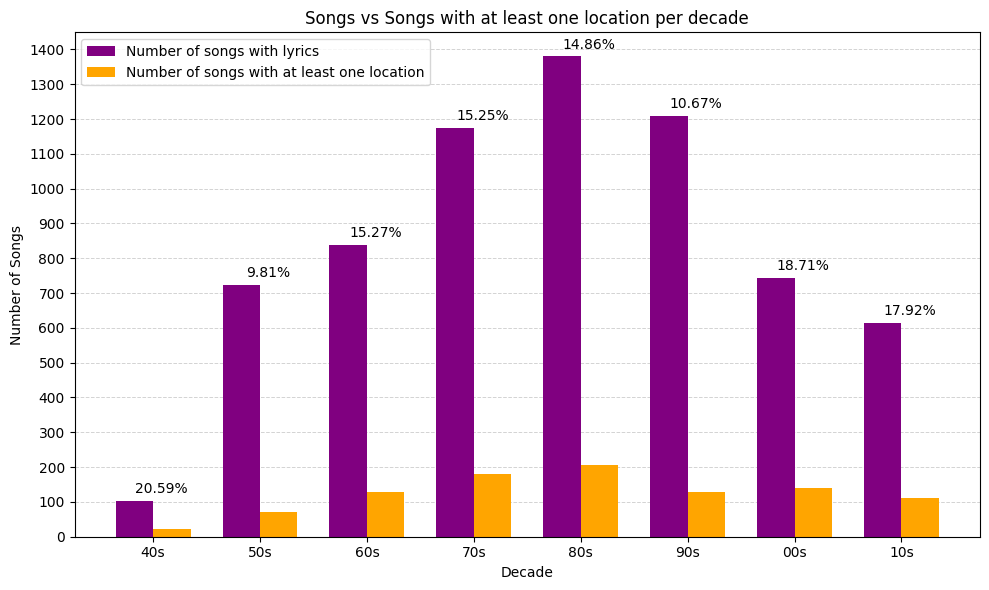

In [80]:
decades = ["40s", "50s", "60s", "70s", "80s", "90s", "00s", "10s"]
lyrics_counts = [forties_lyrics, fifties_lyrics, sixties_lyrics, seventies_lyrics, eighties_lyrics, nineties_lyrics, zeros_lyrics, tens_lyrics]
locs_counts = [forties_locs, fifties_locs, sixties_locs, seventies_locs, eighties_locs, nineties_locs, zeros_locs, tens_locs]

x = np.arange(len(decades))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(x - width/2, lyrics_counts, width, label = "Number of songs with lyrics", color = "purple")
bars2 = ax.bar(x + width/2, locs_counts, width, label = "Number of songs with at least one location", color = "orange")

ax.set_xlabel("Decade")
ax.set_ylabel("Number of Songs")
ax.set_title("Songs vs Songs with at least one location per decade")
ax.set_xticks(x)
ax.set_yticks(np.linspace(0, 1400, 15))
ax.grid(axis="y", color="lightgray", linestyle="--", linewidth=0.7)
ax.set_xticklabels(decades)
ax.set_axisbelow(True)
ax.legend(loc = "upper left")

for i, (total, locs) in enumerate(zip(lyrics_counts, locs_counts)):
    ratio = locs / total
    ax.text(
        x[i]+0.08,
        total + max(lyrics_counts) * 0.01,
        f"{round(ratio * 100, 2)}%",
        ha = "center", va = "bottom", fontsize = 10
    )

plt.tight_layout()
plt.savefig(f"Data/Final/song_statistics", dpi=300, bbox_inches = "tight")

Plots for each city over time (decadewise)

In [82]:
def plot_creator(loc_list):
    for location in loc_list:
        count_40 = 0
        count_50 = 0
        count_60 = 0
        count_70 = 0
        count_80 = 0
        count_90 = 0
        count_00 = 0
        count_10 = 0        
        for year in location["release_years"]:
            if year < 1950:
                count_40 += 1
            elif year < 1960:
                count_50 += 1
            elif year < 1970:
                count_60 += 1
            elif year < 1980:
                count_70 += 1
            elif year < 1990:
                count_80 += 1
            elif year < 2000:
                count_90 += 1
            elif year < 2010:
                count_00 += 1
            else:
                count_10 += 1
        
        counts_all = [count_40, count_50, count_60, count_70, count_80, count_90, count_00, count_10]
        decades = ["40s", "50s", "60s", "70s", "80s", "90s", "00s", "10s"]

        plt.figure(figsize=(8, 4))
        plt.plot(decades, counts_all, marker="o", linewidth=2)

        if "city" in location:
            plt.title(f"Location mentions over time: {location['city']}")
        else:
            plt.title(f"Location mentions over time: {location['state']}")
        plt.xlabel("Decade")
        plt.ylabel("Number of mentions")
        plt.grid(axis="y", linestyle="--", alpha=0.6)

        if "city" in location:
            if len(location["release_years"]) < 10:
                plt.ylim(0, 10)
                plt.yticks(np.linspace(0, 10, 6))
                plt.savefig(f"Data/Final/City_Plots/Small/{location['city']}.png", dpi=300, bbox_inches = "tight")
            elif len(location["release_years"]) < 25:
                plt.ylim(0, 10)
                plt.yticks(np.linspace(0, 10, 6))
                plt.savefig(f"Data/Final/City_Plots/Medium/{location['city']}.png", dpi=300, bbox_inches = "tight")
            else:
                plt.ylim(0, 35)
                plt.yticks(np.linspace(0, 35, 8))
                plt.savefig(f"Data/Final/City_Plots/Large/{location['city']}.png", dpi=300, bbox_inches = "tight")
        else:
            if len(location["release_years"]) < 10:
                plt.ylim(0, 10)
                plt.yticks(np.linspace(0, 10, 6))
                plt.savefig(f"Data/Final/State_Plots/Small/{location['state']}.png", dpi=300, bbox_inches = "tight")
            elif len(location["release_years"]) < 25:
                plt.ylim(0, 10)
                plt.yticks(np.linspace(0, 10, 6))
                plt.savefig(f"Data/Final/State_Plots/Medium/{location['state']}.png", dpi=300, bbox_inches = "tight")
            else:
                plt.ylim(0, 35)
                plt.yticks(np.linspace(0, 35, 8))
                plt.savefig(f"Data/Final/State_Plots/Large/{location['state']}.png", dpi=300, bbox_inches = "tight")
    plt.close()

In [ ]:
with open("Data/Final/final_city_list_clean.json", "r", encoding = "utf-8") as f:
    city_list = json.load(f)
with open("Data/Final/final_state_list.json", "r", encoding = "utf-8") as f:
    state_list = json.load(f)

plot_creator(city_list)
plot_creator(state_list)

Now, the same function but with normalization. Meaning that for every decade, the number of mentions of a city gets divided by the number of songs that have lyrics in the same decade (calculated above). This is done to control for the unequal number of songs per decade. I do not control for the number of songs that mention at least one location because that is just how it is. Maybe in the 80s, singers did not want to sing about locations, that was their decision.

If every song in a decade would mention a city, that city should have a value of 1.

In [90]:
def plot_creator_normalized(loc_list):
    for location in loc_list:
        count_40 = 0
        count_50 = 0
        count_60 = 0
        count_70 = 0
        count_80 = 0
        count_90 = 0
        count_00 = 0
        count_10 = 0        
        for year in location["release_years"]:
            if year < 1950:
                count_40 += 1
            elif year < 1960:
                count_50 += 1
            elif year < 1970:
                count_60 += 1
            elif year < 1980:
                count_70 += 1
            elif year < 1990:
                count_80 += 1
            elif year < 2000:
                count_90 += 1
            elif year < 2010:
                count_00 += 1
            else:
                count_10 += 1
        
        count_40 = round(count_40 / 102*100, 3)
        count_50 = round(count_50 / 724*100, 3)
        count_60 = round(count_60 / 838*100, 3)
        count_70 = round(count_70 / 1174*100, 3)
        count_80 = round(count_80 / 1380*100, 3)
        count_90 = round(count_90 / 1209*100, 3)
        count_00 = round(count_00 / 743*100, 3)
        count_10 = round(count_10 / 614*100, 3)
        
        counts_all = [count_40, count_50, count_60, count_70, count_80, count_90, count_00, count_10]
        decades = ["40s", "50s", "60s", "70s", "80s", "90s", "00s", "10s"]

        plt.figure(figsize=(8, 4))
        plt.plot(decades, counts_all, marker="o", linewidth=2)

        if "city" in location:
            plt.title(f"Normalized location mentions over time: {location['city']}")
        else:
            plt.title(f"Normalized location mentions over time: {location['state']}")
        plt.xlabel("Decade")
        plt.ylabel("Number of mentions per 100 songs")
        plt.grid(axis="y", linestyle="--", alpha=0.6)

        if "city" in location:
            if len(location["release_years"]) < 10:
                plt.ylim(0, 2)
                plt.yticks(np.linspace(0, 2, 5))
                plt.savefig(f"Data/Final/City_Plots_normalized/Small/{location['city']}.png", dpi=300, bbox_inches = "tight")
            elif len(location["release_years"]) < 25:
                plt.ylim(0, 2)
                plt.yticks(np.linspace(0, 2, 5))
                plt.savefig(f"Data/Final/City_Plots_normalized/Medium/{location['city']}.png", dpi=300, bbox_inches = "tight")
            else:
                plt.ylim(0, 4)
                plt.yticks(np.linspace(0, 4, 5))
                plt.savefig(f"Data/Final/City_Plots_normalized/Large/{location['city']}.png", dpi=300, bbox_inches = "tight")
        else:
            if len(location["release_years"]) < 10:
                plt.ylim(0, 2)
                plt.yticks(np.linspace(0, 2, 5))
                plt.savefig(f"Data/Final/State_Plots_normalized/Small/{location['state']}.png", dpi=300, bbox_inches = "tight")
            elif len(location["release_years"]) < 25:
                plt.ylim(0, 2)
                plt.yticks(np.linspace(0, 2, 5))
                plt.savefig(f"Data/Final/State_Plots_normalized/Medium/{location['state']}.png", dpi=300, bbox_inches = "tight")
            else:
                plt.ylim(0, 4)
                plt.yticks(np.linspace(0, 4, 5))
                plt.savefig(f"Data/Final/State_Plots_normalized/Large/{location['state']}.png", dpi=300, bbox_inches = "tight")
    plt.close()

In [ ]:
with open("Data/Final/final_city_list_clean.json", "r", encoding = "utf-8") as f:
    city_list = json.load(f)
with open("Data/Final/final_state_list.json", "r", encoding = "utf-8") as f:
    state_list = json.load(f)

plot_creator_normalized(city_list)
plot_creator_normalized(state_list)

Now, I want to find out, whether the South and the Midwest get mentioned more often than the rest of the US.

In [41]:
with open("Data/Final/final_city_list_clean.json", "r", encoding = "utf-8") as f:
    city_list = json.load(f)

city_south = [0]
city_midwest = [0]
city_rest = [0]
city_south_dec = [0,0,0,0,0,0,0,0]
city_midwest_dec = [0,0,0,0,0,0,0,0]
city_rest_dec = [0,0,0,0,0,0,0,0]

for city in city_list:
    if city.get("state") in ["AL", "AR", "DE", "DC", "FL", "GA", "KY", "LA", "MD", "MS", "NC", "OK", "SC", "TN", "TX", "VA", "WV"]:
        city_south.append(city)
        city_south[0] += city.get("count")
        for year in city.get("release_years"):
            if year < 1950:
                city_south_dec[0] += 1
            elif year < 1960:
                city_south_dec[1] += 1
            elif year < 1970:
                city_south_dec[2] += 1
            elif year < 1980:
                city_south_dec[3] += 1
            elif year < 1990:
                city_south_dec[4] += 1
            elif year < 2000:
                city_south_dec[5] += 1
            elif year < 2010:
                city_south_dec[6] += 1
            else:
                city_south_dec[7] += 1
    elif city.get("state") in ["IL", "IN", "IA", "KS", "MI", "MN", "MO", "NE", "ND", "OH", "SD", "WI"]:
        city_midwest.append(city)
        city_midwest[0] += city.get("count")
        for year in city.get("release_years"):
            if year < 1950:
                city_midwest_dec[0] += 1
            elif year < 1960:
                city_midwest_dec[1] += 1
            elif year < 1970:
                city_midwest_dec[2] += 1
            elif year < 1980:
                city_midwest_dec[3] += 1
            elif year < 1990:
                city_midwest_dec[4] += 1
            elif year < 2000:
                city_midwest_dec[5] += 1
            elif year < 2010:
                city_midwest_dec[6] += 1
            else:
                city_midwest_dec[7] += 1
    else:
        city_rest.append(city)
        city_rest[0] += city.get("count")
        for year in city.get("release_years"):
            if year < 1950:
                city_rest_dec[0] += 1
            elif year < 1960:
                city_rest_dec[1] += 1
            elif year < 1970:
                city_rest_dec[2] += 1
            elif year < 1980:
                city_rest_dec[3] += 1
            elif year < 1990:
                city_rest_dec[4] += 1
            elif year < 2000:
                city_rest_dec[5] += 1
            elif year < 2010:
                city_rest_dec[6] += 1
            else:
                city_rest_dec[7] += 1

city_total = (np.array(city_south_dec) + np.array(city_midwest_dec) + np.array(city_rest_dec))

print(city_south)
print(city_midwest)
print(city_rest)
print(city_south_dec)
print(city_midwest_dec)
print(city_rest_dec)
print(city_total)

[505, {'city': 'Dallas', 'lat': 32.78306, 'lon': -96.80667, 'country': 'US', 'state': 'TX', 'pop': 1326087, 'count': 41, 'release_years': [1946, 1954, 1963, 1964, 1966, 1968, 1968, 1972, 1973, 1975, 1976, 1976, 1976, 1976, 1977, 1977, 1979, 1979, 1980, 1981, 1981, 1984, 1985, 1985, 1985, 1985, 1989, 1991, 1992, 1994, 1995, 1995, 1996, 1997, 1999, 2001, 2014, 2014, 2017, 1998, 1980], 'artists': ['Merle Travis', 'Wanda Jackson', 'Stonewall Jackson', 'George Hamilton IV', 'Buddy Starcher', 'Del Reeves', 'Nat Stuckey', 'Barbara Mandrell', 'Jim Ed Brown', 'Faron Young', 'Mel Tillis', 'Bill Anderson', 'Don Williams', 'Bill Anderson', 'Charley Pride', 'Tanya Tucker', 'Gene Watson', 'Tanya Tucker', 'Tanya Tucker', 'Conway Twitty', 'Eddy Raven', 'Ricky Skaggs', 'George Strait', 'Gary Morris', 'Hank Williams Jr.', 'Sawyer Brown', 'Mary Chapin Carpenter', 'Ray Kennedy', 'Diamond Rio', 'Confederate Railroad', 'Mark Chesnutt', 'Ty England', 'Trace Adkins', 'Tim McGraw', 'Randy Travis', 'George Stra

In [39]:
with open("Data/Final/final_state_list.json", "r", encoding = "utf-8") as f:
    state_list = json.load(f)

state_south = [0]
state_midwest = [0]
state_rest = [0]
state_south_dec = [0,0,0,0,0,0,0,0]
state_midwest_dec = [0,0,0,0,0,0,0,0]
state_rest_dec = [0,0,0,0,0,0,0,0]

for state in state_list:
    if state.get("state") in ["Alabama", "Arkansas", "Delaware", "District of Columbia", "Florida", "Georgia", "Kentucky", "Louisiana", "Maryland", "Mississippi", "North Carolina", "Oklahoma", "South Carolina", "Tennessee", "Texas", "Virginia", "West Virginia"]:
        state_south.append(state)
        state_south[0] += state.get("count")
        for year in state.get("release_years"):
            if year < 1950:
                state_south_dec[0] += 1
            elif year < 1960:
                state_south_dec[1] += 1
            elif year < 1970:
                state_south_dec[2] += 1
            elif year < 1980:
                state_south_dec[3] += 1
            elif year < 1990:
                state_south_dec[4] += 1
            elif year < 2000:
                state_south_dec[5] += 1
            elif year < 2010:
                state_south_dec[6] += 1
            else:
                state_south_dec[7] += 1
    elif state.get("state") in ["Illinois", "Indiana", "Iowa", "Kansas", "Michigan", "Minnesota", "Missouri", "Nebraska", "North Dakota", "Ohio", "South Dakota", "Wisconsin"]:
        state_midwest.append(state)
        state_midwest[0] += state.get("count")
        for year in state.get("release_years"):
            if year < 1950:
                state_midwest_dec[0] += 1
            elif year < 1960:
                state_midwest_dec[1] += 1
            elif year < 1970:
                state_midwest_dec[2] += 1
            elif year < 1980:
                state_midwest_dec[3] += 1
            elif year < 1990:
                state_midwest_dec[4] += 1
            elif year < 2000:
                state_midwest_dec[5] += 1
            elif year < 2010:
                state_midwest_dec[6] += 1
            else:
                state_midwest_dec[7] += 1
    else:
        state_rest.append(state)
        state_rest[0] += state.get("count")
        for year in state.get("release_years"):
            if year < 1950:
                state_rest_dec[0] += 1
            elif year < 1960:
                state_rest_dec[1] += 1
            elif year < 1970:
                state_rest_dec[2] += 1
            elif year < 1980:
                state_rest_dec[3] += 1
            elif year < 1990:
                state_rest_dec[4] += 1
            elif year < 2000:
                state_rest_dec[5] += 1
            elif year < 2010:
                state_rest_dec[6] += 1
            else:
                state_rest_dec[7] += 1

state_total = (np.array(state_south_dec) + np.array(state_midwest_dec) + np.array(state_rest_dec))

print(state_south)
print(state_midwest)
print(state_rest)
print(state_south_dec)
print(state_midwest_dec)
print(state_rest_dec)
print(state_total)

[500, {'state': 'Texas', 'lat': 31.4758, 'lon': -99.3311, 'count': 100, 'release_years': [1944, 1946, 1948, 1948, 1953, 1955, 1960, 1960, 1962, 1962, 1963, 1964, 1965, 1967, 1968, 1968, 1968, 1970, 1970, 1971, 1972, 1974, 1974, 1975, 1975, 1975, 1976, 1976, 1976, 1976, 1976, 1976, 1976, 1977, 1977, 1977, 1978, 1979, 1979, 1979, 1980, 1980, 1980, 1980, 1980, 1980, 1980, 1981, 1983, 1983, 1984, 1984, 1984, 1985, 1985, 1985, 1985, 1985, 1986, 1986, 1986, 1987, 1987, 1988, 1988, 1988, 1988, 1988, 1988, 1989, 1989, 1989, 1989, 1990, 1990, 1991, 1991, 1991, 1992, 1992, 1993, 1993, 1994, 1995, 1995, 1995, 1996, 1996, 1996, 1996, 1997, 1998, 1998, 1999, 1999, 2003, 2005, 2006, 2006, 2010], 'artists': ['Bing Crosby', 'Merle Travis', 'Eddy Arnold', 'Ernest Tubb', 'Hank Snow', 'Ernest Tubb', 'Marty Robbins', 'Webb Pierce', 'Webb Pierce', 'Johnny Cash', 'Lester Flatt', 'George Hamilton IV', 'George Hamilton IV', 'David Houston', 'Dottie West', 'Billy Walker', 'Dave Dudley', 'Jeannie C. Riley', 'Ro

Plot these results

In [46]:
def region_plotter(south_list, midwest_list, rest_list, total_list, location_type):

    decades = ["40s", "50s", "60s", "70s", "80s", "90s", "00s", "10s"]

    x = np.arange(len(decades))
    width = 0.25

    fig, ax = plt.subplots(figsize=(10, 6))

    bars_south = ax.bar(x - width, south_list, width, label="South", color="orange")
    bars_midwest = ax.bar(x, midwest_list, width, label="Midwest", color="purple")
    bars_rest = ax.bar(x + width, rest_list, width, label="Rest", color="grey")

    total_list = total_list

    def add_bar_labels(ax, bars, region_list, total_list, offset = 1.5):
        for i, bar in enumerate(bars):
            number = region_list[i]
            total = total_list[i]

            if total == 0:
                continue
                
            share = number / total * 100

            ax.text(
                bar.get_x() + bar.get_width() / 2,
                number + offset,
                f"{share:.2f}%",
                ha="center",
                va="bottom",
                fontsize=9,
                rotation=90
            )

    add_bar_labels(ax, bars_south, south_list, total_list)
    add_bar_labels(ax, bars_midwest, midwest_list, total_list)
    add_bar_labels(ax, bars_rest, rest_list, total_list)

    ax.set_xlabel("Decade")
    ax.set_ylabel("Number of region mentions")
    ax.set_yticks(np.linspace(0, 150, 16))
    if location_type == "city":
        ax.set_title("Regional distribution of city mentions in country lyrics over time")
    else:
        ax.set_title("Regional distribution of state mentions in country lyrics over time")

    ax.set_xticks(x)
    ax.set_xticklabels(decades)

    ax.legend()
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    ax.set_axisbelow(True)

    if location_type == "city":
        plt.savefig("Data/Final/Region_Plots/city_mentions_by_region_decade.png", dpi=300, bbox_inches="tight")
    else:
        plt.savefig("Data/Final/Region_Plots/state_mentions_by_region_decade.png", dpi=300, bbox_inches="tight")
    return {
        "south": south_list,
        "midwest": midwest_list,
        "rest": rest_list,
        "total": total_list.tolist(),
        "south_share": (np.array(south_list) / total_list).tolist(),
        "midwest_share": (np.array(midwest_list) / total_list).tolist(),
        "rest_share": (np.array(rest_list) / total_list).tolist()
    }

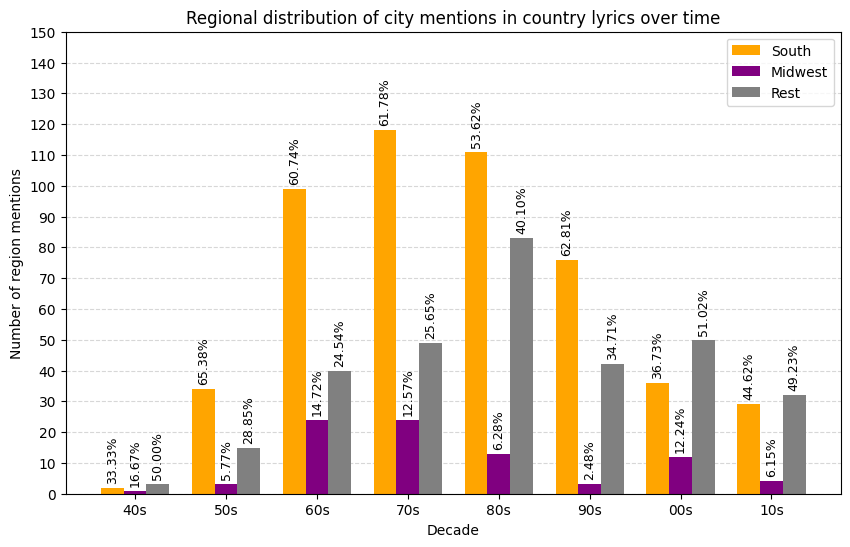

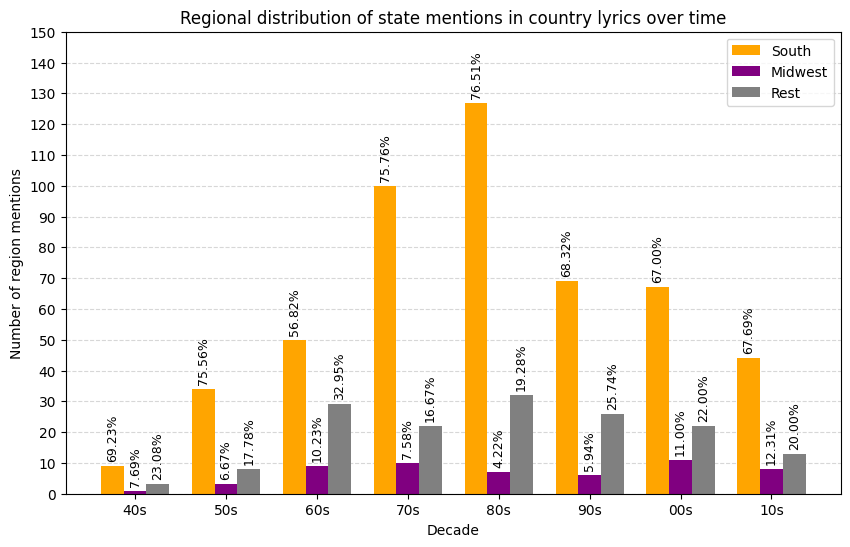

In [47]:
data_region_city = region_plotter(city_south_dec, city_midwest_dec, city_rest_dec, city_total, "city")
data_region_state = region_plotter(state_south_dec, state_midwest_dec, state_rest_dec, state_total, "state")

Now create the same plot for urban/rural cities (threshold 100'000 inhabitants). Not for states because that would not make any sense.

In [141]:
with open("Data/Final/final_city_list_clean.json", "r", encoding = "utf-8") as f:
    city_list = json.load(f)

city_rural = [0]
city_urban = [0]
city_rural_dec = [0,0,0,0,0,0,0,0]
city_urban_dec = [0,0,0,0,0,0,0,0]

for city in city_list:
    if city.get("pop") < 200000:
        city_rural[0] += city.get("count")
        for year in city.get("release_years"):
            if year < 1950:
                city_rural_dec[0] += 1
            elif year < 1960:
                city_rural_dec[1] += 1
            elif year < 1970:
                city_rural_dec[2] += 1
            elif year < 1980:
                city_rural_dec[3] += 1
            elif year < 1990:
                city_rural_dec[4] += 1
            elif year < 2000:
                city_rural_dec[5] += 1
            elif year < 2010:
                city_rural_dec[6] += 1
            else:
                city_rural_dec[7] += 1
    else:
        city_urban[0] += city.get("count")
        for year in city.get("release_years"):
            if year < 1950:
                city_urban_dec[0] += 1
            elif year < 1960:
                city_urban_dec[1] += 1
            elif year < 1970:
                city_urban_dec[2] += 1
            elif year < 1980:
                city_urban_dec[3] += 1
            elif year < 1990:
                city_urban_dec[4] += 1
            elif year < 2000:
                city_urban_dec[5] += 1
            elif year < 2010:
                city_urban_dec[6] += 1
            else:
                city_urban_dec[7] += 1

city_total_urbanity = (np.array(city_rural_dec) + np.array(city_urban_dec))

print(city_rural)
print(city_urban)
print(city_rural_dec)
print(city_urban_dec)
print(city_total_urbanity)

[296]
[607]
[2, 19, 51, 55, 68, 38, 36, 27]
[4, 33, 112, 136, 139, 83, 62, 38]
[  6  52 163 191 207 121  98  65]


In [ ]:
def urbanity_plotter(city_list, threshold_value):
    city_rural = [0]
    city_urban = [0]
    city_rural_dec = [0,0,0,0,0,0,0,0]
    city_urban_dec = [0,0,0,0,0,0,0,0]

    for city in city_list:
        if city.get("pop") < threshold_value:
            city_rural[0] += city.get("count")
            for year in city.get("release_years"):
                if year < 1950:
                    city_rural_dec[0] += 1
                elif year < 1960:
                    city_rural_dec[1] += 1
                elif year < 1970:
                    city_rural_dec[2] += 1
                elif year < 1980:
                    city_rural_dec[3] += 1
                elif year < 1990:
                    city_rural_dec[4] += 1
                elif year < 2000:
                    city_rural_dec[5] += 1
                elif year < 2010:
                    city_rural_dec[6] += 1
                else:
                    city_rural_dec[7] += 1
        else:
            city_urban[0] += city.get("count")
            for year in city.get("release_years"):
                if year < 1950:
                    city_urban_dec[0] += 1
                elif year < 1960:
                    city_urban_dec[1] += 1
                elif year < 1970:
                    city_urban_dec[2] += 1
                elif year < 1980:
                    city_urban_dec[3] += 1
                elif year < 1990:
                    city_urban_dec[4] += 1
                elif year < 2000:
                    city_urban_dec[5] += 1
                elif year < 2010:
                    city_urban_dec[6] += 1
                else:
                    city_urban_dec[7] += 1

    city_total_urbanity = (np.array(city_rural_dec) + np.array(city_urban_dec))

    print(city_rural)
    print(city_urban)
    print(city_rural_dec)
    print(city_urban_dec)
    print(city_total_urbanity)

    decades = ["40s", "50s", "60s", "70s", "80s", "90s", "00s", "10s"]

    x = np.arange(len(decades))
    width = 0.25

    fig, ax = plt.subplots(figsize=(10, 6))

    threshold_value_nice = f"{threshold_value:,}".replace(",","'")
    bars_rural = ax.bar(x - width, city_rural_dec, width, label=f"Rural (< {threshold_value_nice})", color="orange")
    bars_urban = ax.bar(x, city_urban_dec, width, label=f"Urban (>= {threshold_value_nice})", color="purple")

    total_list = city_total_urbanity

    def add_bar_labels(ax, bars, region_list, total_list, offset = 1.5):
        for i, bar in enumerate(bars):
            number = region_list[i]
            total = total_list[i]

            if total == 0:
                continue
                
            share = number / total * 100

            ax.text(
                bar.get_x() + bar.get_width() / 2,
                number + offset,
                f"{share:.2f}%",
                ha="center",
                va="bottom",
                fontsize=9,
                rotation=90
            )

    add_bar_labels(ax, bars_rural, city_rural_dec, total_list)
    add_bar_labels(ax, bars_urban, city_urban_dec, total_list)

    max_height = 0
    for bar in bars_rural:
        if bar.get_height() > max_height:
            max_height = bar.get_height()
    for bar in bars_urban:
        if bar.get_height() > max_height:
            max_height = bar.get_height()
    max_height_rounded = math.ceil(max_height/10) * 10
    ax.set_xlabel("Decade")
    ax.set_ylabel("Number of city mentions")
    ax.set_yticks(np.linspace(0, max_height_rounded + 20, int((max_height_rounded+20)/10+1)))
    ax.set_title(f"Mentions of rural vs. urban locations in country music over time (threshold: {threshold_value_nice} inhabitants)")

    ax.set_xticks(x-0.125)
    ax.set_xticklabels(decades)

    ax.legend()
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    ax.set_axisbelow(True)

    plt.savefig(f"Data/Final/Urbanity_Plots/city_mentions_by_urbanity_decade_{threshold_value_nice}.png", dpi=300, bbox_inches="tight")
    return {
        "rural": city_rural_dec,
        "urban": city_urban_dec,
        "total": city_total_urbanity.tolist(),
        "urban_share": (np.array(city_urban_dec) / city_total_urbanity).tolist(),
        "rural_share": (np.array(city_rural_dec) / city_total_urbanity).tolist()
    }

[714]
[189]
[6, 49, 136, 158, 142, 100, 76, 47]
[0, 3, 27, 33, 65, 21, 22, 18]
[  6  52 163 191 207 121  98  65]
[438]
[465]
[3, 35, 85, 89, 90, 59, 46, 31]
[3, 17, 78, 102, 117, 62, 52, 34]
[  6  52 163 191 207 121  98  65]
[296]
[607]
[2, 19, 51, 55, 68, 38, 36, 27]
[4, 33, 112, 136, 139, 83, 62, 38]
[  6  52 163 191 207 121  98  65]


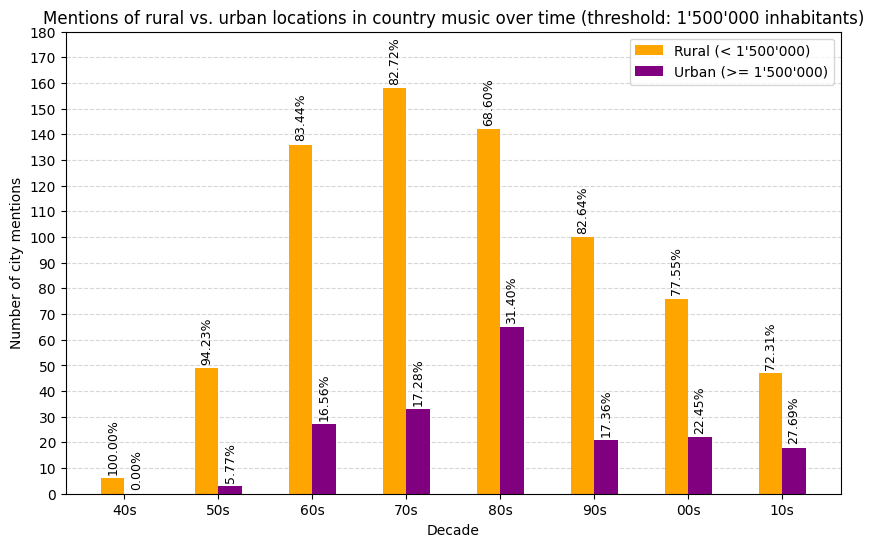

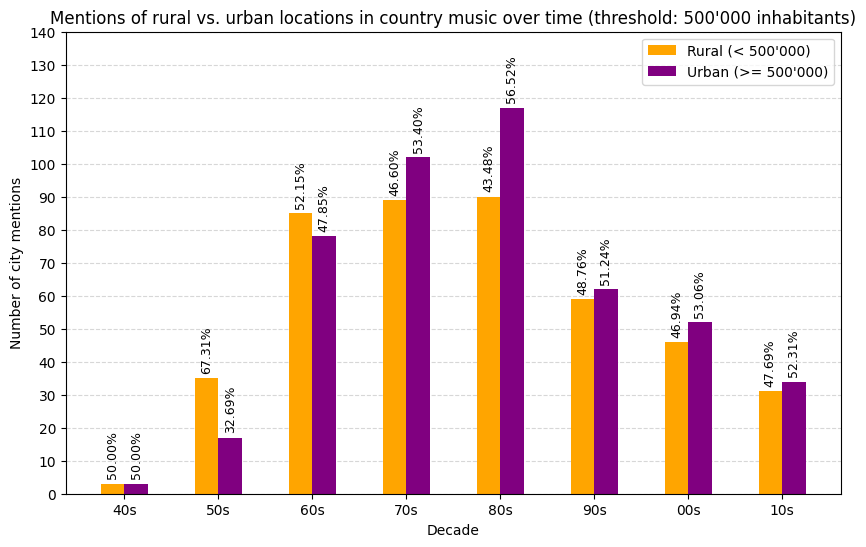

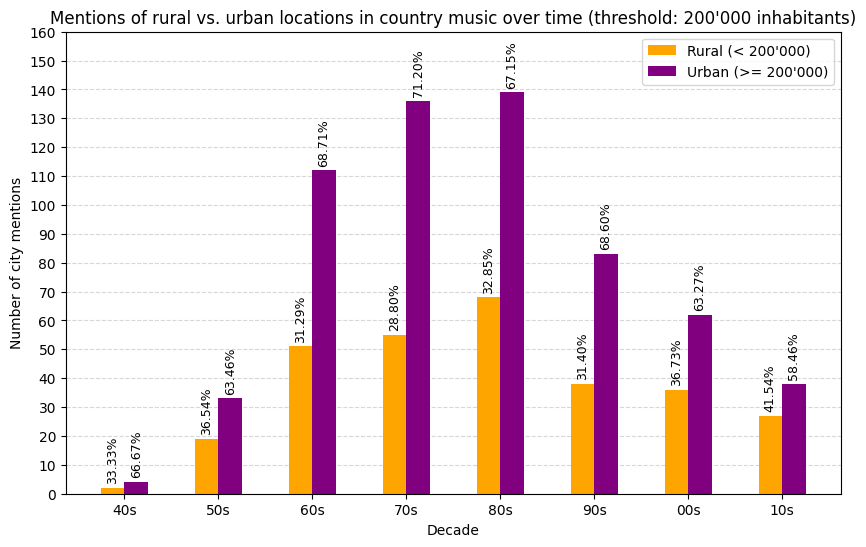

In [58]:
with open("Data/Final/final_city_list_clean.json", "r", encoding = "utf-8") as f:
    city_list = json.load(f)

data_urbanity_1500000 = urbanity_plotter(city_list, 1500000)
data_urbanity_500000 = urbanity_plotter(city_list, 500000)
data_urbanity_200000 = urbanity_plotter(city_list, 200000)

Spearman Rank (for regions)

In [61]:
time = np.arange(1, 9)
# stats for regions (south, midwest, rest)

print(f"south absolute: {spearmanr(time, data_region_city['south'])}")
print(spearmanr(time, data_region_city["south_share"]))
print(spearmanr(time, data_region_city["midwest"]))
print(spearmanr(time, data_region_city["midwest_share"]))
print(spearmanr(time, data_region_city["rest"]))
print(spearmanr(time, data_region_city["rest_share"]))
print(spearmanr(time, data_region_state["south"]))
print(spearmanr(time, data_region_state["south_share"]))
print(spearmanr(time, data_region_state["midwest"]))
print(spearmanr(time, data_region_state["midwest_share"]))
print(spearmanr(time, data_region_state["rest"]))
print(spearmanr(time, data_region_state["rest_share"]))

time_80s = time[4:]
print(spearmanr(time_80s, data_region_city["south"][4:]))
print(spearmanr(time_80s, data_region_city["south_share"][4:]))
print(spearmanr(time_80s, data_region_city["midwest"][4:]))
print(spearmanr(time_80s, data_region_city["midwest_share"][4:]))
print(spearmanr(time_80s, data_region_city["rest"][4:]))
print(spearmanr(time_80s, data_region_city["rest_share"][4:]))
print(spearmanr(time_80s, data_region_state["south"][4:]))
print(spearmanr(time_80s, data_region_state["south_share"][4:]))
print(spearmanr(time_80s, data_region_state["midwest"][4:]))
print(spearmanr(time_80s, data_region_state["midwest_share"][4:]))
print(spearmanr(time_80s, data_region_state["rest"][4:]))
print(spearmanr(time_80s, data_region_state["rest_share"][4:]))

south absolute: SignificanceResult(statistic=np.float64(0.09523809523809526), pvalue=np.float64(0.8225054302036114))
SignificanceResult(statistic=np.float64(-0.14285714285714288), pvalue=np.float64(0.735764859879812))
SignificanceResult(statistic=np.float64(0.20483414440254896), pvalue=np.float64(0.6265435481779082))
SignificanceResult(statistic=np.float64(-0.4761904761904762), pvalue=np.float64(0.23293553465009798))
SignificanceResult(statistic=np.float64(0.523809523809524), pvalue=np.float64(0.18272075053971482))
SignificanceResult(statistic=np.float64(0.3571428571428572), pvalue=np.float64(0.3851206435562562))
SignificanceResult(statistic=np.float64(0.4285714285714286), pvalue=np.float64(0.2894032248467901))
SignificanceResult(statistic=np.float64(-0.28571428571428575), pvalue=np.float64(0.4927262450169573))
SignificanceResult(statistic=np.float64(0.5476190476190477), pvalue=np.float64(0.1600256425388966))
SignificanceResult(statistic=np.float64(0.30952380952380953), pvalue=np.float

Quadratic regression (for regions)

In [70]:
regions = ["south", "midwest", "rest", "south_share", "midwest_share", "rest_share"]
time_c = np.arange(1, 9) - 4.5  #center it
X = np.column_stack([time_c, time_c**2])
X = sm.add_constant(X)
results_list_cities = []
for region in regions:
    y = np.array(data_region_city[region])
    model = sm.OLS(y, X).fit()
    for var, coef, se, tval, pval in zip(["const","linear","quadratic"], model.params, model.bse, model.tvalues, model.pvalues):
        results_list_cities.append({
            "Region": region,
            "Variable": var,
            "Coef": round(coef, 2),
            "StdErr": round(se, 2),
            "t": round(tval, 2),
            "p": round(pval, 3),
            "R2": round(model.rsquared, 2)
        })

df_results_cities = pd.DataFrame(results_list_cities)
print(df_results_cities)



regions = ["south", "midwest", "rest", "south_share", "midwest_share", "rest_share"]
time_c = np.arange(1, 9) - 4.5  #center it
X = np.column_stack([time_c, time_c**2])
X = sm.add_constant(X)
results_list_state = []
for region in regions:
    y = np.array(data_region_state[region])
    model = sm.OLS(y, X).fit()
    for var, coef, se, tval, pval in zip(["const","linear","quadratic"], model.params, model.bse, model.tvalues, model.pvalues):
        results_list_state.append({
            "Region": region,
            "Variable": var,
            "Coef": round(coef, 2),
            "StdErr": round(se, 2),
            "t": round(tval, 2),
            "p": round(pval, 3),
            "R2": round(model.rsquared, 2)
        })

df_results_state = pd.DataFrame(results_list_state)
print(df_results_state)

           Region   Variable    Coef  StdErr      t      p    R2
0           south      const  106.34   10.10  10.53  0.000  0.87
1           south     linear    1.46    2.90   0.50  0.635  0.87
2           south  quadratic   -8.23    1.45  -5.68  0.002  0.87
3         midwest      const   17.25    4.43   3.89  0.012  0.45
4         midwest     linear   -0.10    1.27  -0.07  0.943  0.45
5         midwest  quadratic   -1.29    0.64  -2.02  0.099  0.45
6            rest      const   57.88    7.34   7.88  0.001  0.77
7            rest     linear    4.98    2.11   2.36  0.065  0.77
8            rest  quadratic   -3.55    1.05  -3.37  0.020  0.77
9     south_share      const    0.62    0.06  11.01  0.000  0.51
10    south_share     linear   -0.01    0.02  -0.49  0.645  0.51
11    south_share  quadratic   -0.02    0.01  -2.22  0.077  0.51
12  midwest_share      const    0.09    0.03   3.12  0.026  0.27
13  midwest_share     linear   -0.01    0.01  -1.26  0.262  0.27
14  midwest_share  quadra

Spearman rank (for Urbanity)

In [59]:
time = np.arange(1, 9)
# stats for urbanity

print(spearmanr(time, data_urbanity_1500000["rural"]))
print(spearmanr(time, data_urbanity_1500000["rural_share"]))
print(spearmanr(time, data_urbanity_1500000["urban"]))
print(spearmanr(time, data_urbanity_1500000["urban_share"]))
print(spearmanr(time, data_urbanity_500000["rural"]))
print(spearmanr(time, data_urbanity_500000["rural_share"]))
print(spearmanr(time, data_urbanity_500000["urban"]))
print(spearmanr(time, data_urbanity_500000["urban_share"]))
print(spearmanr(time, data_urbanity_200000["rural"]))
print(spearmanr(time, data_urbanity_200000["rural_share"]))
print(spearmanr(time, data_urbanity_200000["urban"]))
print(spearmanr(time, data_urbanity_200000["urban_share"]))

time_80s = time[4:]
print(spearmanr(time_80s, data_urbanity_1500000["rural"][4:]))
print(spearmanr(time_80s, data_urbanity_1500000["rural_share"][4:]))
print(spearmanr(time_80s, data_urbanity_1500000["urban"][4:]))
print(spearmanr(time_80s, data_urbanity_1500000["urban_share"][4:]))
print(spearmanr(time_80s, data_urbanity_500000["rural"][4:]))
print(spearmanr(time_80s, data_urbanity_500000["rural_share"][4:]))
print(spearmanr(time_80s, data_urbanity_500000["urban"][4:]))
print(spearmanr(time_80s, data_urbanity_500000["urban_share"][4:]))
print(spearmanr(time_80s, data_urbanity_200000["rural"][4:]))
print(spearmanr(time_80s, data_urbanity_200000["rural_share"][4:]))
print(spearmanr(time_80s, data_urbanity_200000["urban"][4:]))
print(spearmanr(time_80s, data_urbanity_200000["urban_share"][4:]))

SignificanceResult(statistic=np.float64(0.09523809523809526), pvalue=np.float64(0.8225054302036114))
SignificanceResult(statistic=np.float64(-0.8571428571428572), pvalue=np.float64(0.006530017254715292))
SignificanceResult(statistic=np.float64(0.28571428571428575), pvalue=np.float64(0.4927262450169573))
SignificanceResult(statistic=np.float64(0.8571428571428572), pvalue=np.float64(0.006530017254715292))
SignificanceResult(statistic=np.float64(0.11904761904761905), pvalue=np.float64(0.7788857260523797))
SignificanceResult(statistic=np.float64(-0.5476190476190477), pvalue=np.float64(0.1600256425388966))
SignificanceResult(statistic=np.float64(0.261904761904762), pvalue=np.float64(0.530922861565801))
SignificanceResult(statistic=np.float64(0.5476190476190477), pvalue=np.float64(0.1600256425388966))
SignificanceResult(statistic=np.float64(0.261904761904762), pvalue=np.float64(0.530922861565801))
SignificanceResult(statistic=np.float64(0.38095238095238104), pvalue=np.float64(0.3518125531175

Quadratic regression (for urbanity)

In [73]:
urbanity = ["rural", "urban", "rural_share", "urban_share"]
time_c = np.arange(1, 9) - 4.5  #center it
X = np.column_stack([time_c, time_c**2])
X = sm.add_constant(X)
results_list_15 = []
for urbanity_type in urbanity:
    y = np.array(data_urbanity_1500000[urbanity_type])
    model = sm.OLS(y, X).fit()
    for var, coef, se, tval, pval in zip(["const","linear","quadratic"], model.params, model.bse, model.tvalues, model.pvalues):
        results_list_15.append({
            "Urbanity": urbanity_type,
            "Variable": var,
            "Coef": round(coef, 2),
            "StdErr": round(se, 2),
            "t": round(tval, 2),
            "p": round(pval, 3),
            "R2": round(model.rsquared, 2)
        })

df_results_15 = pd.DataFrame(results_list_15)
print(df_results_15)


urbanity = ["rural", "urban", "rural_share", "urban_share"]
time_c = np.arange(1, 9) - 4.5  #center it
X = np.column_stack([time_c, time_c**2])
X = sm.add_constant(X)
results_list_5 = []
for urbanity_type in urbanity:
    y = np.array(data_urbanity_500000[urbanity_type])
    model = sm.OLS(y, X).fit()
    for var, coef, se, tval, pval in zip(["const","linear","quadratic"], model.params, model.bse, model.tvalues, model.pvalues):
        results_list_5.append({
            "Urbanity": urbanity_type,
            "Variable": var,
            "Coef": round(coef, 2),
            "StdErr": round(se, 2),
            "t": round(tval, 2),
            "p": round(pval, 3),
            "R2": round(model.rsquared, 2)
        })

df_results_5 = pd.DataFrame(results_list_5)
print(df_results_5)


urbanity = ["rural", "urban", "rural_share", "urban_share"]
time_c = np.arange(1, 9) - 4.5  #center it
X = np.column_stack([time_c, time_c**2])
X = sm.add_constant(X)
results_list_2 = []
for urbanity_type in urbanity:
    y = np.array(data_urbanity_200000[urbanity_type])
    model = sm.OLS(y, X).fit()
    for var, coef, se, tval, pval in zip(["const","linear","quadratic"], model.params, model.bse, model.tvalues, model.pvalues):
        results_list_2.append({
            "Urbanity": urbanity_type,
            "Variable": var,
            "Coef": round(coef, 2),
            "StdErr": round(se, 2),
            "t": round(tval, 2),
            "p": round(pval, 3),
            "R2": round(model.rsquared, 2)
        })

df_results_2 = pd.DataFrame(results_list_2)
print(df_results_2)

       Urbanity   Variable    Coef  StdErr      t      p    R2
0         rural      const  142.75   11.65  12.26  0.000  0.88
1         rural     linear    3.55    3.34   1.06  0.337  0.88
2         rural  quadratic  -10.19    1.67  -6.10  0.002  0.88
3         urban      const   38.72    8.04   4.81  0.005  0.61
4         urban     linear    2.80    2.31   1.21  0.280  0.61
5         urban  quadratic   -2.88    1.15  -2.49  0.055  0.61
6   rural_share      const    0.79    0.03  25.73  0.000  0.79
7   rural_share     linear   -0.03    0.01  -3.98  0.011  0.79
8   rural_share  quadratic    0.01    0.00   1.67  0.156  0.79
9   urban_share      const    0.21    0.03   6.91  0.001  0.79
10  urban_share     linear    0.03    0.01   3.98  0.011  0.79
11  urban_share  quadratic   -0.01    0.00  -1.67  0.156  0.79
       Urbanity   Variable   Coef  StdErr      t      p    R2
0         rural      const  86.25    6.92  12.46  0.000  0.88
1         rural     linear   2.07    1.99   1.04  0.345  